# Spatial MultiCP (SCMCP) — Probability-Space Spatially-Smoothed Multi-Head Conformal Prediction

**Method:** For each of the K model heads, the softmax **probability** map is spatially
smoothed (neighbourhood averaging) and then **renormalised** so every pixel's class
probabilities sum to 1 again. APS/SAPS nonconformity scores are computed *only after*
this step, so the score function always operates on a valid probability distribution.
Per-head quantile thresholds are calibrated on these scores. At inference, smoothed
scores from every head must jointly satisfy their thresholds — the final prediction set
is the **intersection** across all heads, and coverage / set size are reported on this
intersected set.

This combines:
- **Multi-CP** tight prediction sets via K-head intersection
- **Spatial smoothing** of softmax probabilities, with renormalisation, for spatial
  coherence — applied *before* APS/SAPS scores are computed

| Section | Content |
|---------|--------|
| 1 | Setup & Imports |
| 2 | Configuration |
| 3 | Custom Keras Layers |
| 4 | Data Pipeline |
| 5 | Model Loading |
| 6 | Core Algorithm: Spatial MultiCP (SCMCP) |
| 7 | Utility & Plotting Helpers |
| 8 | Main Execution Loop |
| 9 | Cross-Window Combined Summary |
| 10 | Final Validation |

# 1.0 — Setup & Imports

Mount Google Drive (when running in Colab), install extra packages, then import all required libraries.

## 1.1 — Colab Environment Setup

Conditionally mounts Google Drive and installs `xlsxwriter`, `openpyxl`, and `tqdm` when running inside Google Colab.

In [1]:
import os
import sys
import subprocess

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', 'xlsxwriter', 'openpyxl', 'tqdm'],
        check=True
    )

## 1.2 — Library Imports

Imports the full scientific stack (NumPy, pandas, matplotlib, seaborn, scipy, sklearn), Excel export libraries, and TensorFlow/Keras.

In [2]:
# Standard library
import io
import gc
import json
import math
import time
import random
import re
import warnings
from pathlib import Path

from scipy.io import loadmat

# Third-party — scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from matplotlib import cm
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Excel export
from openpyxl import Workbook, load_workbook
from openpyxl.drawing.image import Image as XLImage
from openpyxl.utils.dataframe import dataframe_to_rows

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K, layers, activations, optimizers
from tensorflow.keras.layers import (
    Input, Add, Multiply, Reshape, Dense, Activation, BatchNormalization,
    Flatten, Dropout, concatenate, Lambda,
    Conv2D, AveragePooling2D, MaxPooling2D, GlobalAveragePooling2D,
    GlobalAvgPool2D, DepthwiseConv2D, SeparableConv2D, MaxPool2D, UpSampling2D,
    Conv2DTranspose, add, multiply, LayerNormalization,
)
from tensorflow.python.util.tf_export import keras_export
from tensorflow.python.ops import array_ops
from tensorflow.python.keras.utils import control_flow_util
from tensorflow.keras.models import load_model, Model

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print('Python    :', sys.version.split()[0])
print('TensorFlow:', tf.__version__)

Python    : 3.12.13
TensorFlow: 2.20.0


# 2.0 — Configuration

All tunable constants, file paths, and hyperparameters live here. **Only edit this section between experiments.**

## 2.1 — Seeds, Paths & Data Geometry

Sets global random seeds for reproducibility, defines all file-system paths, and establishes spatial dimensions and split fractions for the dataset.

In [3]:

import os
import random
import numpy as np
import tensorflow as tf
from pathlib import Path

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_ROOT = Path('/kaggle/working')

OUTPUT_DIR = Path('/kaggle/working')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = Path('/kaggle/input/dias-dataset-k01')
for p in Path('/kaggle/input').glob('**/k001.mat'):
    DATA_DIR = p.parent
    break
DATA_FILE = DATA_DIR / 'k001.mat'
LABEL_FILE = DATA_DIR / 'k002.mat'

MULTICP_DIR = Path('/kaggle/input/dias-multicp-models')
for p in Path('/kaggle/input').glob('**/k031.keras'):
    MULTICP_DIR = p.parent
    break
MODEL_DIR = MULTICP_DIR
MODEL_REGISTRY_PATH = MODEL_DIR / 'model_registry_multihead.json'

H, W, B = None, None, None
PERCENTILE_CLIP = (2.0, 98.0)
PATCH_SIZE = 9
TRAIN_PERCENT = 0.75
CALIB_FRACTION_OF_TEST = 0.5
BATCH_SIZE = 128
EPS = 1e-12


## 2.2 — Conformal Prediction & SACP Hyperparameters

Sets ALPHA, scoring methods, ensemble/class counts (NUM_CLASSES inferred automatically once the scene is loaded), SACP spatial-smoothing parameters, and the colour palette.

In [4]:
# Conformal prediction
ALPHA              = 0.05
SCORING_METHODS    = ['RAPS', 'SAPS']
K_HEADS            = 7   # multi-head ensemble size — architectural choice, unrelated to class count
# NUM_CLASSES is inferred automatically from the loaded label map in Section 4.2
NUM_CLASSES        = None
UNCERTAIN_FRACTION = 0.10   # top fraction of pixels labelled uncertain in scene map

# SACP spatial smoothing — applied PER HEAD before calibration
SACP_LAMBDA       = 0.5          # blend weight: smoothed = lambda*original + lambda*neighbour_mean
SACP_K            = 1            # number of smoothing iterations
SACP_WINDOW_SIZES = [3, 5, 7, 9] # outer sweep: all window sizes to evaluate

# Top-level combined output paths (written after all window loops finish)
COMBINED_SUMMARY_CSV  = OUTPUT_DIR / 'combined_summary_all_windows.csv'
COMBINED_PERCLASS_CSV = OUTPUT_DIR / 'combined_per_class_all_windows.csv'

# Colour palettes — same bold, saturated base used across the other notebooks,
# extended to a base of 10 (covers the new 8-class dataset), with additional
# bold shades (same style) generated on the fly if a future dataset needs more.
import colorsys

CLASS_COLOR_BASE = [
    '#0000FF', '#00FF00', '#FF0000', '#00FFFF', '#FF00FF',
    '#FFFF00', '#A52A2A', '#FFA500', '#7FFF00', '#8A2BE2',
]
UNCERTAIN_COLOR     = '#808080'
CERTAIN_COLOR       = '#FFFF00'
UNCERTAIN_MAP_COLOR = '#001F3F'
BINARY_UNCERTAINTY_CMAP = ListedColormap([CERTAIN_COLOR, UNCERTAIN_MAP_COLOR])

def _generate_extra_shades(n_extra, hue_offset=0.05, sat=0.85, val=0.95):
    """Bold, highly-saturated extra hues in the same style as CLASS_COLOR_BASE."""
    shades = []
    for i in range(n_extra):
        hue = (hue_offset + i / max(n_extra, 1)) % 1.0
        r, g, b = colorsys.hsv_to_rgb(hue, sat, val)
        shades.append('#%02x%02x%02x' % (int(r * 255), int(g * 255), int(b * 255)))
    return shades

def get_class_colors(n):
    """Return n distinct hex colours, extending the base 10 with additional bold
    shades in the same saturated style if needed."""
    if n <= len(CLASS_COLOR_BASE):
        return CLASS_COLOR_BASE[:n]
    return CLASS_COLOR_BASE + _generate_extra_shades(n - len(CLASS_COLOR_BASE))

def resolve_uncertain_color(class_colors, preferred=UNCERTAIN_COLOR, min_dist=60):
    """Return `preferred` unless it visually clashes with any class colour, in
    which case fall back to a distinct dark slate so 'Uncertain' never collides
    with a real class colour."""
    def _hex_to_rgb(h):
        h = h.lstrip('#')
        return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))
    pr, pg, pb = _hex_to_rgb(preferred)
    for c in class_colors:
        cr, cg, cb = _hex_to_rgb(c)
        dist = ((pr - cr) ** 2 + (pg - cg) ** 2 + (pb - cb) ** 2) ** 0.5
        if dist < min_dist:
            return '#2F2F2F'
    return preferred

# CLASS_COLORS is finalised once NUM_CLASSES is known (Section 4.2)
CLASS_COLORS = None

MODEL_NAME_MAP = {
    'AlexNet_CNN_MultiHead': 'AlexNet',
    'GFNet_MultiHead'      : 'GFNet',
    'ViT_UNet_MultiHead'   : 'ViT',
}

TRUSTED_MODEL_ROOTS = [MODEL_DIR]

print('Window sizes to sweep:', SACP_WINDOW_SIZES)
print('Scoring methods      :', SCORING_METHODS)

Window sizes to sweep: [3, 5, 7, 9]
Scoring methods      : ['RAPS', 'SAPS']


## 2.3 — Clone & Import Multi-CP Repository

Clones `https://github.com/yamtawa/Multi-CP` once and adds it to `sys.path` to import `compute_scores`.

In [5]:
repo_path = PROJECT_ROOT / 'Multi-CP'
if not repo_path.exists():
    subprocess.run(
        ['git', 'clone', 'https://github.com/yamtawa/Multi-CP.git', str(repo_path)],
        check=True,
    )
if str(repo_path) not in sys.path:
    sys.path.append(str(repo_path))

from utils import compute_scores
print('Multi-CP repo:', repo_path)

Cloning into '/kaggle/working/Multi-CP'...


Multi-CP repo: /kaggle/working/Multi-CP


# 3.0 — Custom Keras Layers

All bespoke layer classes required by `load_model`. **Do not edit unless retraining.**

Includes layers for AlexNet (Pearson attention, structured dropout), GFNet (patch extraction, positional encoding, global frequency filter), and ViT (spatial attention, Transformer blocks, CLS token norm).

## 3.1 — AlexNet Layers

Defines `Pearson_correlation_masked` (pixel-wise attention via Pearson correlation) and `Dropout_Train` (deterministic structured dropout used during progressive training shifts).

In [6]:
class Pearson_correlation_masked(layers.Layer):
    """Pixel-wise Pearson-correlation attention — masks pixels below mean correlation."""
    def __init__(self, P_S=9, **kwargs):
        super().__init__(**kwargs)
        self.P_S = P_S

    def call(self, inputs):
        loc      = self.P_S // 2
        channels = inputs.shape[-1]
        x_mean   = tf.repeat(tf.math.reduce_mean(inputs, axis=-1, keepdims=True), channels, axis=-1)
        y        = tf.repeat(tf.repeat(inputs[:, loc:loc+1, loc:loc+1, :], self.P_S, axis=-2), self.P_S, axis=-3)
        y_mean   = tf.repeat(tf.math.reduce_mean(y, axis=-1, keepdims=True), channels, axis=-1)
        a, b     = inputs - x_mean, y - y_mean
        num      = tf.reduce_sum(a * b,   axis=-1, keepdims=True)
        deno     = tf.sqrt(tf.reduce_sum(a*a, axis=-1, keepdims=True) *
                           tf.reduce_sum(b*b, axis=-1, keepdims=True))
        corr     = num / deno
        mask     = tf.cast(corr > tf.reduce_mean(corr), corr.dtype)
        attention_weights = tf.repeat(mask * corr, channels, axis=-1)
        return multiply([inputs, attention_weights])

    def get_config(self):
        cfg = super().get_config(); cfg.update({'P_S': self.P_S}); return cfg


@keras_export('keras.layers.Dropout')
class Dropout_Train(layers.Layer):
    """Deterministic structured dropout used during progressive training shifts."""
    def __init__(self, rate, shift=1, noise_shape=None, seed=None, **kwargs):
        super().__init__(**kwargs)
        if not 0 <= rate <= 1:
            raise ValueError(f'Invalid rate {rate}')
        if type(shift) != int:
            raise TypeError(f'shift must be int, got {type(shift)}')
        if shift * rate > 1.0:
            raise ValueError(f'shift {shift} too large for rate {rate}')
        self.rate, self.shift = rate, shift
        self.noise_shape, self.seed = noise_shape, seed
        self.supports_masking = True

    def _get_noise_shape(self, inputs):
        """Resolve concrete noise shape from symbolic or None spec."""
        if self.noise_shape is None:
            return None
        concrete = array_ops.shape(inputs)
        return tf.convert_to_tensor(
            [concrete[i] if v is None else v for i, v in enumerate(self.noise_shape)])

    def call(self, inputs, training=None):
        """Apply structured dropout mask during training; identity at inference."""
        if self.rate == 0:
            return tf.identity(inputs)
        if training is None:
            training = K.learning_phase()
        def dropped_inputs():
            sz   = inputs.shape[-1]
            r0   = int(self.rate * (self.shift - 1) * sz)
            r1   = int(self.rate * self.shift * sz) if self.shift * self.rate < 1.0 else None
            mult = np.ones(sz); mult[r0:r1] = 0.0
            return Multiply()([inputs, tf.constant(mult)])
        return control_flow_util.smart_cond(
            training, dropped_inputs, lambda: array_ops.identity(inputs))

    def compute_output_shape(self, input_shape): return input_shape

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'rate': self.rate, 'shift': self.shift,
                    'noise_shape': self.noise_shape, 'seed': self.seed,
                    'supports_masking': self.supports_masking})
        return cfg

## 3.2 — GFNet Layers

Defines `GF_Patches` (non-overlapping patch extraction), `GF_PatchEncoder` (projection + positional embeddings), and `GF_GlobalFilter` (learnable 2-D frequency filter via FFT — the GFNet core block).

In [7]:
@tf.keras.utils.register_keras_serializable()
class GF_MLP(layers.Layer):
    """Two-layer GELU MLP used inside GF_Block."""
    def __init__(self, in_features, out_features, drop=0.0, **kwargs):
        super().__init__(**kwargs)
        self.in_features = in_features
        self.out_features = out_features
        self.drop = drop
        self.mlp_1 = layers.Dense(in_features, activation=tf.keras.activations.gelu, use_bias=False)
        self.mlp_2 = layers.Dense(out_features, activation=tf.keras.activations.gelu, use_bias=False)
        self.drop_1 = layers.Dropout(drop)
        self.drop_2 = layers.Dropout(drop)

    def call(self, x):
        return self.drop_2(self.mlp_2(self.drop_1(self.mlp_1(x))))

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'in_features': self.in_features, 'out_features': self.out_features, 'drop': self.drop})
        return cfg


@tf.keras.utils.register_keras_serializable()
class GF_DropPath(layers.Layer):
    """Stochastic depth / drop-path regularisation."""
    def __init__(self, drop_prob=0.0, training=False, **kwargs):
        super().__init__(**kwargs)
        self.drop_prob = drop_prob
        self.training = training

    def call(self, x, **kwargs):
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = keep_prob + tf.random.uniform(shape, dtype=x.dtype)
        random_tensor = tf.floor(random_tensor)
        return tf.divide(x, keep_prob) * random_tensor

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'drop_prob': self.drop_prob, 'training': self.training})
        return cfg


@tf.keras.utils.register_keras_serializable()
class GF_Expand_Dims(layers.Layer):
    """Wrap tf.expand_dims as a serializable Keras layer."""
    def __init__(self, ndim, **kwargs):
        super().__init__(**kwargs)
        self.ndim = ndim

    def call(self, x):
        return tf.expand_dims(x, axis=self.ndim)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'ndim': self.ndim})
        return cfg


@tf.keras.utils.register_keras_serializable()
class GF_Patches(layers.Layer):
    """Extract image patches using the legacy GFNet config contract."""
    def __init__(self, patch_size=3, hidden_dim=256, patch_method='extract', **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.hidden_dim = hidden_dim
        self.patch_method = patch_method.lower() if isinstance(patch_method, str) else patch_method

    def call(self, images):
        if self.patch_method == 'conv':
            x = layers.Conv2D(self.hidden_dim, self.patch_size, self.patch_size)(images)
            return layers.Reshape([-1, x.shape[-1]])(x)
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID',
        )
        return tf.reshape(patches, [batch_size, -1, patches.shape[-1]])

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'patch_size': self.patch_size, 'hidden_dim': self.hidden_dim, 'patch_method': self.patch_method})
        return cfg


@tf.keras.utils.register_keras_serializable()
class GF_PatchEncoder(layers.Layer):
    """Linear projection plus positional embedding for GFNet patches."""
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(num_patches, projection_dim)

    def call(self, patch, **kwargs):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return self.projection(patch) + self.position_embedding(positions)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'num_patches': self.num_patches, 'projection_dim': self.projection_dim})
        return cfg


@tf.keras.utils.register_keras_serializable()
class GF_GlobalFilter(layers.Layer):
    """Learnable frequency-domain filter via 2-D real FFT."""
    def __init__(self, patch_size, dim, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.dim = dim

    def build(self, input_shape):
        self.complex_weight = self.add_weight(
            name='complex_weight',
            shape=(self.patch_size, self.patch_size, input_shape[-1] // 2 + 1, 2),
            initializer=tf.random_uniform_initializer(),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, x, **kwargs):
        _, token_count, channels = x.shape
        token_side = int(math.sqrt(token_count))
        x = tf.reshape(x, [-1, token_side, token_side, channels])
        x = tf.signal.rfft2d(x)
        x = x * tf.dtypes.complex(self.complex_weight[:, :, :, 0], self.complex_weight[:, :, :, -1])
        x = tf.signal.irfft2d(x)
        return tf.reshape(x, [-1, token_count, channels])

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'patch_size': self.patch_size, 'dim': self.dim})
        return cfg


@tf.keras.utils.register_keras_serializable()
class GF_Block(layers.Layer):
    """Single GFNet transformer-style residual block."""
    def __init__(self, patch_size=3, dim=512, mlp_ratio=4.0, drop=0.0, drop_path=0.0, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.dim = dim
        self.mlp_ratio = mlp_ratio
        self.drop = drop
        self.drop_path_rate = drop_path
        self.norm1 = layers.LayerNormalization(axis=-1)
        self.filter = GF_GlobalFilter(patch_size, dim)
        self.drop_path = GF_DropPath(drop_path)
        self.norm2 = layers.LayerNormalization(axis=-1)
        self.mlp = GF_MLP(int(dim * mlp_ratio), dim, drop)

    def call(self, x):
        return x + self.drop_path(self.mlp(self.norm2(self.filter(self.norm1(x)))))

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'patch_size': self.patch_size, 'dim': self.dim, 'mlp_ratio': self.mlp_ratio, 'drop': self.drop, 'drop_path': self.drop_path_rate})
        return cfg


## 3.3 — ViT Layers

Defines all Vision Transformer components: spatial attention branches, patch extraction, positional encoding with CLS token, weighted residual addition, Transformer encoder blocks with U-Net skip connections, and CLS token normalisation. Finishes by registering all custom objects in `CUSTOM_OBJECTS` for `load_model`.

In [8]:
class ViT_SpatialAttention(layers.Layer):
    """Lightweight 4-conv spatial attention branch."""
    def __init__(self, k_size=3, **kwargs):
        super().__init__(**kwargs); self.k_size = k_size
        self.norm    = layers.BatchNormalization()
        self.conv1   = layers.Conv2D(1, k_size, padding='same')
        self.conv2   = layers.Conv2D(1, k_size, padding='same')
        self.conv3   = layers.Conv2D(1, k_size, padding='same')
        self.conv4   = layers.Conv2D(1, k_size, padding='same')
        self.relu    = layers.Activation('relu')
        self.sigmoid = layers.Activation('sigmoid')

    def call(self, inputs):
        x = self.relu(self.conv2(self.norm(self.conv1(inputs))))
        x = self.relu(self.conv3(x))
        return self.sigmoid(self.conv4(x))

    def get_config(self):
        cfg = super().get_config(); cfg.update({'k_size': self.k_size}); return cfg


class ViT_SpatialAttention1(layers.Layer):
    """Encoder-decoder spatial attention with strided Conv + ConvTranspose."""
    def __init__(self, input_shape, **kwargs):
        super().__init__(**kwargs)
        self.input_shape_val = input_shape
        self.filters = input_shape[-1]; self.k_size = input_shape[1]
        self.norm   = layers.BatchNormalization()
        self.conv1  = layers.Conv2D(self.filters, 3, padding='same', kernel_initializer='he_normal')
        self.conv2  = layers.Conv2D(self.filters, 3, strides=2, padding='same')
        self.conv3  = layers.Conv2D(self.filters, 3, strides=2, padding='same')
        self.convt1 = layers.Conv2DTranspose(self.filters, 3, strides=2, padding='same')
        self.convt2 = layers.Conv2DTranspose(self.filters, 3, strides=2, padding='same')
        self.relu    = layers.ReLU()
        self.sigmoid = layers.Activation('sigmoid')

    def call(self, inputs):
        x = self.relu(self.norm(self.conv1(inputs)))
        x = self.relu(self.conv2(x)); x = self.relu(self.conv3(x))
        x = self.relu(self.convt1(x)); x = self.relu(self.convt2(x))
        if x.shape[1] != self.input_shape_val[1] or x.shape[2] != self.input_shape_val[2]:
            kk = x.shape[1] - self.k_size + 1
            x  = layers.Conv2D(self.filters, kk, strides=1, padding='valid')(x)
        return self.sigmoid(x)

    def get_config(self):
        cfg = super().get_config(); cfg.update({'input_shape': self.input_shape_val}); return cfg


def MLP(x, hidden_units, dropout_rate):
    """Feedforward MLP used inside ViT Transformer blocks."""
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.keras.activations.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x


class ViT_Patches(layers.Layer):
    """Extract non-overlapping patches and project to embed_dim."""
    def __init__(self, patch_size, embed_dim=768, **kwargs):
        super().__init__(**kwargs); self.patch_size, self.embed_dim = patch_size, embed_dim

    def build(self, input_shape):
        self.projection = layers.Dense(self.embed_dim)

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1], padding='VALID')
        patches = tf.reshape(patches, [batch_size, -1, patches.shape[-1]])
        return self.projection(patches)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'patch_size': self.patch_size, 'embed_dim': self.embed_dim}); return cfg


class ViT_PatchEncoder(layers.Layer):
    """Linear projection + CLS token + positional embedding."""
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches, self.projection_dim = num_patches, projection_dim
        self.projection         = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(num_patches + 1, projection_dim)
        self.cls_token = self.add_weight(
            name='cls_token', shape=(1, 1, projection_dim),
            initializer=tf.zeros_initializer(), trainable=True)

    def call(self, patch, **kwargs):
        batch_size = tf.shape(patch)[0]
        cls_tokens = tf.repeat(self.cls_token, batch_size, axis=0)
        x          = tf.concat([cls_tokens, self.projection(patch)], axis=1)
        positions  = tf.range(start=0, limit=self.num_patches + 1, delta=1)
        return x + self.position_embedding(positions)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'num_patches': self.num_patches, 'projection_dim': self.projection_dim}); return cfg


class ViT_Weighted_add(layers.Layer):
    """Learnable weighted residual: out = w*a + (1-w)*b."""
    def __init__(self, name, **kwargs):
        super().__init__(**kwargs); self.wt_name = name

    def build(self, input_shape):
        self.w = self.add_weight(name=f'weighted_add_{self.wt_name}', shape=(1,),
                                  initializer=tf.random_normal_initializer(), trainable=True)

    def call(self, a, b): return a * self.w + b * (1.0 - self.w)

    def get_config(self):
        cfg = super().get_config(); cfg.update({'wt_name': self.wt_name}); return cfg


class ViT_TransFormer(layers.Layer):
    """Single Transformer encoder block with learned-weight residuals."""
    def __init__(self, layer_num, num_heads, projection_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.layer_num, self.num_heads = layer_num, num_heads
        self.projection_dim, self.dropout = projection_dim, dropout

    def build(self, input_shape):
        self.norm1 = layers.LayerNormalization(epsilon=1e-6, name=f'ln1_{self.layer_num}')
        self.norm2 = layers.LayerNormalization(epsilon=1e-6, name=f'ln2_{self.layer_num}')
        self.add1  = ViT_Weighted_add(f'transformer_1_{self.layer_num}')
        self.add2  = ViT_Weighted_add(f'transformer_2_{self.layer_num}')
        self.mha   = layers.MultiHeadAttention(
            num_heads=self.num_heads, key_dim=self.projection_dim,
            dropout=self.dropout, name=f'mha_{self.layer_num}')
        self.dense1 = layers.Dense(self.projection_dim * 2, activation=tf.keras.activations.gelu)
        self.dense2 = layers.Dense(self.projection_dim,     activation=tf.keras.activations.gelu)
        self.drop1  = layers.Dropout(self.dropout)
        self.drop2  = layers.Dropout(self.dropout)

    def call(self, inputs, training=None):
        x1 = self.add1(self.mha(self.norm1(inputs), self.norm1(inputs), training=training), inputs)
        x2 = self.drop1(self.dense1(self.norm2(x1)), training=training)
        x2 = self.drop2(self.dense2(x2), training=training)
        return self.add2(x2, x1)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'layer_num': self.layer_num, 'num_heads': self.num_heads,
                    'projection_dim': self.projection_dim, 'dropout': self.dropout}); return cfg


class ViT_TransFormer_Block(layers.Layer):
    """Stack of ViT_TransFormer layers with U-Net-style symmetric skip connections."""
    def __init__(self, num_layers, num_heads, projection_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.num_layers, self.num_heads = num_layers, num_heads
        self.projection_dim, self.dropout = projection_dim, dropout

    def build(self, input_shape):
        self.Blocks = [ViT_TransFormer(i, self.num_heads, self.projection_dim, self.dropout)
                       for i in range(self.num_layers)]

    def call(self, inputs, training=None):
        stack, x = [], inputs
        for i, blk in enumerate(self.Blocks):
            x = blk(x, training=training)
            if i <= self.num_layers // 2:
                stack.append(x)
            else:
                x = layers.Add()([x, stack[self.num_layers - i - 1]])
        return x

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'num_layers': self.num_layers, 'num_heads': self.num_heads,
                    'projection_dim': self.projection_dim, 'dropout': self.dropout}); return cfg


class ViT_Class_Token_Norm(layers.Layer):
    """Layer-normalise full sequence then return CLS token (index 0)."""
    def __init__(self, eps=1e-6, **kwargs):
        super().__init__(**kwargs); self.eps = eps
        self.norm = layers.LayerNormalization(epsilon=eps)

    def call(self, inputs): return self.norm(inputs)[:, 0, :]

    def get_config(self):
        cfg = super().get_config(); cfg.update({'eps': self.eps}); return cfg


# ── Custom objects registry (passed to load_model) ────────────────────────────
CUSTOM_OBJECTS = {
    'Pearson_correlation_masked' : Pearson_correlation_masked,
    'Dropout_Train'              : Dropout_Train,
    'GF_Patches'                 : GF_Patches,
    'GF_PatchEncoder'            : GF_PatchEncoder,
    'GF_GlobalFilter'            : GF_GlobalFilter,
    'GF_Block'                   : GF_Block,
    'GF_Expand_Dims'             : GF_Expand_Dims,
    'GF_MLP'                     : GF_MLP,
    'GF_DropPath'                : GF_DropPath,
    'ViT_Patches'                : ViT_Patches,
    'ViT_PatchEncoder'           : ViT_PatchEncoder,
    'ViT_SpatialAttention'       : ViT_SpatialAttention,
    'ViT_SpatialAttention1'      : ViT_SpatialAttention1,
    'ViT_Weighted_add'           : ViT_Weighted_add,
    'ViT_TransFormer'            : ViT_TransFormer,
    'ViT_TransFormer_Block'      : ViT_TransFormer_Block,
    'ViT_Class_Token_Norm'       : ViT_Class_Token_Norm,
}
print('Custom objects registered:', list(CUSTOM_OBJECTS.keys()))


Custom objects registered: ['Pearson_correlation_masked', 'Dropout_Train', 'GF_Patches', 'GF_PatchEncoder', 'GF_GlobalFilter', 'GF_Block', 'GF_Expand_Dims', 'GF_MLP', 'GF_DropPath', 'ViT_Patches', 'ViT_PatchEncoder', 'ViT_SpatialAttention', 'ViT_SpatialAttention1', 'ViT_Weighted_add', 'ViT_TransFormer', 'ViT_TransFormer_Block', 'ViT_Class_Token_Norm']


# 4.0 — Data Pipeline

Loads the hyperspectral/multispectral scene from .mat files, extracts labeled patches with pixel coordinates, then stratified-splits into train / calibration / evaluation sets.

## 4.1 — Data Loading & Patch Extraction Functions

Defines three reusable functions: `load_scene_from_mat` (loads .mat files with robust per-band percentile normalisation), `extract_labeled_patches_with_coords` (centred patch extraction with spatial coordinates), and `split_calib_eval_with_coords` (stratified calibration/evaluation split).

In [9]:
def load_scene_from_mat(data_path, label_path, data_key=None, label_key=None):
    """Load a hyperspectral/multispectral scene + reference labels from .mat files.

    Auto-detects the variable name inside each .mat file if not given (matches
    files such as k001.mat / k002.mat storing the array under a single named
    variable). Each spectral band is robustly stretched to [0, 1] using a
    percentile clip (PERCENTILE_CLIP) rather than literal min/max — a handful of
    saturated/no-data pixels (e.g. sensor clipping at int8 range limits -128/127)
    would otherwise dominate the stretch.
    """
    def _first_array(mat_dict, key):
        if key is not None:
            return mat_dict[key]
        candidates = [v for k, v in mat_dict.items() if not k.startswith('__')]
        if not candidates:
            raise ValueError(f'No data arrays found in {mat_dict.keys()}')
        return candidates[0]

    data_mat  = loadmat(data_path)
    label_mat = loadmat(label_path)

    x = _first_array(data_mat, data_key).astype(np.float32)
    y = _first_array(label_mat, label_key).astype(np.int32)

    if x.ndim != 3:
        raise ValueError(f'Expected a (H, W, Bands) cube, got shape {x.shape}')
    if y.shape != x.shape[:2]:
        raise ValueError(f'Label shape {y.shape} does not match image shape {x.shape[:2]}')

    height, width, bands = x.shape

    x_norm = np.empty_like(x, dtype=np.float32)
    for bi in range(bands):
        band = x[:, :, bi]
        lo   = np.percentile(band, PERCENTILE_CLIP[0])
        hi   = np.percentile(band, PERCENTILE_CLIP[1])
        denom = max(hi - lo, 1e-8)
        x_norm[:, :, bi] = np.clip((band - lo) / denom, 0.0, 1.0)

    return x_norm, y, height, width, bands


def extract_labeled_patches_with_coords(x_img, y_img, patch_size=9):
    """Extract patches centred on every labeled pixel; returns patches, labels, coords."""
    pad   = patch_size // 2
    x_pad = np.pad(x_img, ((pad, pad), (pad, pad), (0, 0)), mode='edge')
    coords    = np.argwhere(y_img > 0)
    x_patches = np.empty((coords.shape[0], patch_size, patch_size, x_img.shape[-1]), dtype=np.float32)
    y_labels  = np.empty((coords.shape[0],), dtype=np.int32)
    for i, (r, c) in enumerate(coords):
        x_patches[i] = x_pad[r:r + patch_size, c:c + patch_size, :]
        y_labels[i]  = int(y_img[r, c]) - 1   # 0-indexed classes
    return x_patches, y_labels, coords


def split_calib_eval_with_coords(x_test, y_test, coords_test, seed=42, calib_fraction=0.5):
    """Stratified split of the test pool into calibration and evaluation sets."""
    test_size = 1.0 - calib_fraction
    try:
        return train_test_split(x_test, y_test, coords_test,
                                test_size=test_size, random_state=seed, stratify=y_test)
    except ValueError:
        return train_test_split(x_test, y_test, coords_test,
                                test_size=test_size, random_state=seed, stratify=None)

## 4.2 — Run the Data Pipeline

Executes the full pipeline: loads the image, builds the padded copy for full-scene inference, extracts labeled patches, and produces the train/calibration/evaluation split.

In [10]:
x_img, y_img, H, W, B = load_scene_from_mat(DATA_FILE, LABEL_FILE)
print('Scene geometry: H=%d  W=%d  Bands=%d' % (H, W, B))
print('x_img:', x_img.shape, '| y_img:', y_img.shape)

# Padded image used for full-scene patch extraction
pad_w    = PATCH_SIZE // 2
padded_x = np.pad(x_img, [(pad_w, pad_w), (pad_w, pad_w), (0, 0)], 'edge')

X_all, y_all, coords_all = extract_labeled_patches_with_coords(x_img, y_img, PATCH_SIZE)
num_classes = int(np.unique(y_all).size)
NUM_CLASSES = num_classes
CLASS_COLORS = get_class_colors(NUM_CLASSES)

_, x_test_pool, _, y_test_pool, _, coords_test_pool = train_test_split(
    X_all, y_all, coords_all,
    train_size=TRAIN_PERCENT, random_state=SEED, stratify=y_all)

x_cal, x_eval, y_cal, y_eval, coords_cal, coords_eval = split_calib_eval_with_coords(
    x_test_pool, y_test_pool, coords_test_pool,
    seed=SEED, calib_fraction=CALIB_FRACTION_OF_TEST)

print('num_classes :', num_classes)
print('x_cal       :', x_cal.shape, '| x_eval:', x_eval.shape)
print('coords_cal  :', coords_cal.shape, '| coords_eval:', coords_eval.shape)

Scene geometry: H=512  W=512  Bands=65
x_img: (512, 512, 65) | y_img: (512, 512)
num_classes : 8
x_cal       : (6737, 9, 9, 65) | x_eval: (6737, 9, 9, 65)
coords_cal  : (6737, 2) | coords_eval: (6737, 2)


# 5.0 — Model Loading

Loads all multi-head models from the JSON registry with a path-trust check, then runs a smoke test to verify output shapes.

## 5.1 — Registry Loader & Trust Check

Defines `is_trusted_model_path` (guards against loading models from untrusted directories) and `load_registry_models` (loads each model from the JSON registry with a two-stage fallback for safe_mode / Lambda layer issues).

In [11]:
TRUSTED_MODEL_ROOTS = [
    MODEL_DIR,
    PROJECT_ROOT / 'multicp' / 'models',
    PROJECT_ROOT / 'sacp' / 'models',
]

def is_trusted_model_path(path):
    """Return True only if path is inside one of the pre-approved root directories."""
    p = Path(path).expanduser().resolve()
    for root in TRUSTED_MODEL_ROOTS:
        r = Path(root).expanduser().resolve()
        if p == r or r in p.parents:
            return True
    return False


def describe_load_error(err, custom_objects):
    """Return a compact, actionable load-model error message."""
    msg = str(err)
    hints = []
    if 'Unrecognized keyword arguments passed to' in msg:
        hints.append('Constructor mismatch between the saved model config and the local custom layer definition.')
    if 'could not be deserialized properly' in msg:
        hints.append('A custom layer or model config does not match the class contract used when the model was saved.')
    missing = re.findall(r"Could not locate class '([^']+)'", msg)
    if missing:
        missing_txt = ', '.join(sorted(set(missing)))
        hints.append(f'Missing custom class registration: {missing_txt}.')
    if hints:
        hints.append(f'Available custom objects: {sorted(custom_objects.keys())}')
        return msg + '\nHints: ' + ' '.join(hints)
    return msg


def load_registry_models(registry_path, custom_objects):
    """Load all models listed in the JSON registry; returns (registry_dict, {model_key: model})."""
    registry = json.loads(Path(registry_path).read_text())
    loaded = {}
    for model_key, info in registry.items():
        path = MODEL_DIR / Path(info['best_model_path']).name
        print(f'Loading {model_key} from {path}')
        if not is_trusted_model_path(path):
            raise RuntimeError(f'Untrusted model path: {path}')
        first_err = None
        try:
            model = keras.models.load_model(
                path, custom_objects=custom_objects, compile=False, safe_mode=False
            )
            loaded[model_key] = model
            print(f'  OK: {model_key}')
            continue
        except Exception as err:
            first_err = err
            print(f'  Primary load failed for {model_key}: {describe_load_error(err, custom_objects)}')
        if 'lambda' in str(first_err).lower() or 'safe_mode' in str(first_err).lower():
            try:
                keras.config.enable_unsafe_deserialization()
                model = keras.models.load_model(
                    path, custom_objects=custom_objects, compile=False, safe_mode=False
                )
                loaded[model_key] = model
                print(f'  Fallback OK: {model_key}')
                continue
            except Exception as second_err:
                raise RuntimeError(
                    f'Failed to load {model_key}.\n'
                    f'Primary: {describe_load_error(first_err, custom_objects)}\n'
                    f'Fallback: {describe_load_error(second_err, custom_objects)}'
                )
        raise RuntimeError(f'Failed to load {model_key}. Error: {describe_load_error(first_err, custom_objects)}')
    return registry, loaded

## 5.2 — Load Models & Smoke Test

Calls `load_registry_models` and verifies each model produces the correct number of heads and class dimensions on a small batch.

In [12]:
registry, models = load_registry_models(MODEL_REGISTRY_PATH, CUSTOM_OBJECTS)

# Smoke test — verify multi-head output shape and numerical validity on a small batch
x_smoke = x_eval[:8]
for key, model in models.items():
    outs = model.predict(x_smoke, verbose=0)
    if isinstance(outs, tuple):
        outs = list(outs)
    elif not isinstance(outs, list):
        outs = [outs]
    assert len(outs) > 0, f'{key}: model returned no heads'
    for head_idx, head_out in enumerate(outs, start=1):
        assert head_out.ndim == 2, f'{key}: head {head_idx} expected rank-2 output, got {head_out.shape}'
        assert head_out.shape[1] == num_classes, f'{key}: head {head_idx} unexpected class dim {head_out.shape[1]}'
        assert np.isfinite(head_out).all(), f'{key}: head {head_idx} contains NaN/Inf values'
    print(f'{key}: {len(outs)} heads, first head shape {outs[0].shape}')
print('All models loaded and verified.')


Loading AlexNet_CNN_MultiHead from /kaggle/input/datasets/daneshselwal/dias-multicp-models/k031.keras


I0000 00:00:1789631608.469659      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789631608.476172      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


  OK: AlexNet_CNN_MultiHead
AlexNet_CNN_MultiHead: 7 heads, first head shape (8, 8)
All models loaded and verified.


I0000 00:00:1789631615.418937      82 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


# 6.0 — Core Algorithm: Spatial MultiCP (SCMCP)

**The key integration point.**

Standard Multi-CP computes per-head quantile thresholds on raw APS/SAPS scores derived
directly from softmax outputs. Here, each head's **softmax probability map** is first
spatially smoothed (neighbourhood averaging) and **renormalised** so it remains a valid
probability distribution, and *only then* are APS/SAPS scores computed from the smoothed
probabilities. Calibration quantiles are extracted from these scores. The downstream
MultiCP intersection predicate (`pred_sets.all(axis=0)`), head sweep, and binary scene
map logic are otherwise identical to MultiCP — but coverage and set size are now reported
on the **final intersected** prediction set.

## 6.1 — Multi-Head Inference Helpers

Defines `get_multihead_outputs` (batched inference returning stacked (K, N, C) softmax outputs) and `get_image_multi_head_outputs` (full scene inference by extracting every pixel patch from the padded image).

In [13]:
def get_multihead_outputs(model, x_data, batch_size=128):
    """Return stacked multi-head softmax outputs, shape (K, N, C)."""
    outputs = model.predict(x_data, batch_size=batch_size, verbose=0)
    if not isinstance(outputs, list):
        outputs = [outputs]
    return np.stack(outputs, axis=0)


def get_image_multi_head_outputs(model, padded_x, H, W, B, P_S, batch_size=32):
    """Extract every pixel patch from padded_x and return multi-head predictions (K, H*W, C)."""
    N       = H * W
    patches = np.zeros((N, P_S, P_S, B), dtype=padded_x.dtype)
    idx     = 0
    for i in range(H):
        for j in range(W):
            patches[idx] = padded_x[i:i + P_S, j:j + P_S, :]
            idx += 1
    return np.stack(model.predict(patches, batch_size=batch_size, verbose=0), axis=0)

## 6.2 — MultiCP Calibration Helpers

Defines `generate_Dcal_Dcells_sets` (splits calibration scores into Dcells/D_re_cal
subsets) and `main_algo` (computes per-head quantile thresholds, the MultiCP
intersection `joint_pred = pred_sets.all(axis=0)`, and returns coverage and the
**final intersected set size**, along with the per-head prediction set booleans).

In [14]:
def generate_Dcal_Dcells_sets(cal_scores, cal_target, fraction=0.05, seed=42):
    """Split calibration scores into Dcells (cell-selection) and D_re_cal subsets."""
    K, N, _   = cal_scores.shape
    rng       = np.random.default_rng(seed)
    n_cells   = max(1, int(N * fraction))
    idx_cells = rng.choice(N, n_cells, replace=False)
    Dcells_scores = cal_scores[:, idx_cells, cal_target[idx_cells].astype(int)].T
    Dcells_target = cal_target[idx_cells]
    mask           = np.ones(N, dtype=bool); mask[idx_cells] = False
    Dre_cal_scores = cal_scores[:, mask, :]
    Dre_cal_target = cal_target[mask]
    return Dcells_scores, Dcells_target, Dre_cal_scores, Dre_cal_target


def main_algo(Dcells_scores, Dcells_target, Dre_cal_scores, Dre_cal_target,
              test_scores, test_target, alpha, config):
    """
    Core MultiCP conformal inference: compute per-head quantile thresholds,
    per-head prediction sets, and the final MultiCP intersection set.

    Coverage and mean set size are reported on the **intersected** prediction
    set (joint_pred = pred_sets.all(axis=0)) — i.e. the set the user actually
    receives — not on a per-head average set size.
    """
    K, N_cal = Dre_cal_scores.shape[0], Dre_cal_scores.shape[1]
    cal_true = Dre_cal_scores[np.arange(K)[:, None], np.arange(N_cal), Dre_cal_target]
    q        = np.quantile(cal_true, 1 - alpha, axis=1)
    pred_sets = test_scores <= q[:, None, None]               # (K, N_test, C) — per-head sets

    # MultiCP intersection — a label is in the final set only if ALL heads include it
    joint_pred = pred_sets.all(axis=0)                          # (N_test, C)

    valid   = (test_target >= 0) & (test_target < joint_pred.shape[1])
    covered = joint_pred[np.arange(np.sum(valid)), test_target[valid]]

    # Final intersected set size (Stage 11) — NOT pred_sets.sum(axis=2).mean()
    set_size = joint_pred.sum(axis=1)

    return covered.mean(), set_size.mean(), pred_sets

## 6.3 — Spatial MultiCP (SCMCP) Probability Smoothing

Defines `build_neighbour_offsets` (computes (dr, dc) offset pairs for a given window
size), `spatial_smooth_prob_map` (one pass of neighbourhood averaging over a 2-D
**softmax probability** map for a single class channel, followed by renormalisation
across classes), and `build_spatially_smoothed_probs` (applies per-head, per-class
smoothing iteratively to a `(K, N, C)` softmax output array and returns a renormalised
`(K, N, C)` probability array — ready to be passed into `compute_scores`).

In [15]:
def build_neighbour_offsets(window_size):
    """Return list of (dr, dc) neighbour offsets for the given window size."""
    assert window_size >= 3 and window_size % 2 == 1, (
        f'window_size must be an odd integer >= 3, got {window_size}')
    radius = window_size // 2
    return [(dr, dc)
            for dr in range(-radius, radius + 1)
            for dc in range(-radius, radius + 1)
            if not (dr == 0 and dc == 0)]


def spatial_smooth_prob_map(prob_map, mask_map, neighbors, lambda_=0.5, eps=EPS):
    """
    One pass of neighbourhood averaging over a 2-D softmax PROBABILITY map for one head,
    followed by renormalisation so every pixel's class probabilities sum to 1 again.

    smoothed = (1 - lambda_) * original + lambda_ * neighbour_mean   (per class channel)

    Parameters
    ----------
    prob_map  : ndarray (H, W, C) — softmax probabilities for one head
    mask_map  : ndarray (H, W) bool — True where a pixel has a probability vector
    neighbors : list of (dr, dc) tuples from build_neighbour_offsets()
    lambda_   : float in (0, 1] — weight on the neighbourhood mean
    eps       : small constant to avoid division by zero during renormalisation

    Returns
    -------
    smoothed : ndarray (H, W, C) — spatially smoothed AND renormalised probabilities
    """
    smoothed = np.copy(prob_map)
    H, W, C  = prob_map.shape
    rows, cols = np.where(mask_map)
    for r, c in zip(rows, cols):
        ori     = prob_map[r, c]
        n_sum   = np.zeros(C)
        n_count = 0
        for dr, dc in neighbors:
            nr, nc = r + dr, c + dc
            if 0 <= nr < H and 0 <= nc < W and mask_map[nr, nc]:
                n_sum   += prob_map[nr, nc]
                n_count += 1
        if n_count > 0:
            n_mean        = n_sum / n_count
            smoothed[r, c] = (1.0 - lambda_) * ori + lambda_ * n_mean

    # ── Renormalisation (mandatory) — restore sum(p) == 1 at every smoothed pixel ──
    sums = smoothed[mask_map].sum(axis=-1, keepdims=True)
    smoothed[mask_map] = smoothed[mask_map] / np.maximum(sums, eps)
    return smoothed


def build_spatially_smoothed_probs(
    raw_probs,    # (K, N, C) — multi-head softmax probabilities for N pixels
    coords,       # (N, 2) — spatial coordinates of those pixels
    H, W,
    neighbors,
    lambda_=0.5,
    k_iters=1,
):
    """
    Apply SCMCP probability-space spatial smoothing + renormalisation to each
    head's softmax output independently.

    For each of the K heads:
      1. Place the (N, C) probability vectors into an (H, W, C) spatial map.
      2. Run k_iters iterations of neighbourhood averaging, renormalising after
         every iteration so probabilities remain a valid distribution.
      3. Read back the smoothed probabilities at the original pixel coordinates.

    Returns
    -------
    smoothed_probs : ndarray (K, N, C) — same shape as input, spatially smoothed
                     and renormalised softmax probabilities (sums to 1 per pixel).
    """
    K, N, C = raw_probs.shape
    smoothed_probs = np.zeros_like(raw_probs, dtype=np.float64)

    # Shared mask — True wherever any pixel has a probability vector
    mask_map = np.zeros((H, W), dtype=bool)
    for r, c in coords:
        mask_map[r, c] = True

    for k in range(K):
        # Populate spatial map for head k
        prob_map = np.zeros((H, W, C), dtype=np.float64)
        for i, (r, c) in enumerate(coords):
            prob_map[r, c] = raw_probs[k, i]

        # Iterative smoothing + renormalisation
        current = prob_map
        for _ in range(k_iters):
            current = spatial_smooth_prob_map(current, mask_map, neighbors, lambda_)

        # Read back smoothed, renormalised probabilities at pixel coordinates
        for i, (r, c) in enumerate(coords):
            smoothed_probs[k, i] = current[r, c]

    return smoothed_probs

## 6.4 — Fused Head Sweep (SCMCP)

Defines `compute_head_sweep_fused`: applies per-head SCMCP spatial smoothing +
renormalisation to the **softmax probability outputs** — calibration and evaluation
pixels are smoothed in **separate** spatial volumes (never mixed) — then computes
APS/SAPS scores on the smoothed, renormalised probabilities, and runs the standard
MultiCP head sweep (1..K) on those scores. Returns a per-head metrics DataFrame and the
final `(config, Dc, Dt, Rc, Rt, pred_sets)` bundle at the full-K step.

In [16]:
def compute_head_sweep_fused(
    cal_output, test_output,
    cal_target, test_target,
    coords_cal, coords_eval,
    scoring_method,
    window_size,
    lambda_=0.5,
    k_iters=1,
):
    """
    Fused Spatial MultiCP (SCMCP) head sweep — probability-space smoothing.

    1. Apply per-head spatial smoothing + renormalisation directly to the (K, N, C)
       softmax probability outputs. Calibration and evaluation pixels are smoothed
       in SEPARATE spatial volumes (Stage 6) — never mixed — to avoid
       calibration/test leakage.
    2. Compute APS/SAPS nonconformity scores on the smoothed, renormalised
       probabilities (Stage 5) — the score function now always sees a valid
       probability distribution.
    3. Run the standard Multi-CP head sweep on the resulting scores.

    Returns
    -------
    head_df     : DataFrame with columns [heads, coverage, set_size]
    last_bundle : (config, Dc, Dt, Rc, Rt, pred_sets) at the full-K step
    """
    config    = {'ALPHA': ALPHA, 'SCORING_METHOD': scoring_method}
    neighbors = build_neighbour_offsets(window_size)

    # ── Probability-space smoothing — calibration and evaluation kept separate ──
    cal_probs_smooth = build_spatially_smoothed_probs(
        cal_output, coords_cal, H, W,
        neighbors=neighbors, lambda_=lambda_, k_iters=k_iters)   # (K, N_cal, C)

    test_probs_smooth = build_spatially_smoothed_probs(
        test_output, coords_eval, H, W,
        neighbors=neighbors, lambda_=lambda_, k_iters=k_iters)   # (K, N_eval, C)

    # ── APS/SAPS scores computed on smoothed, renormalised probabilities ────────
    cal_scores_smooth  = np.round(compute_scores(cal_probs_smooth,  config), 4)
    test_scores_smooth = np.round(compute_scores(test_probs_smooth, config), 4)

    # MultiCP head sweep on smoothed-probability-derived scores
    rows, last_bundle = [], None
    for nH in range(1, cal_output.shape[0] + 1):
        Dc, Dt, Rc, Rt = generate_Dcal_Dcells_sets(
            cal_scores_smooth[:nH], cal_target)
        cov, msz, pred_sets = main_algo(
            Dc, Dt, Rc, Rt,
            test_scores_smooth[:nH], test_target,
            ALPHA, config)
        rows.append({'heads': nH, 'coverage': float(cov), 'set_size': float(msz)})
        if nH == cal_output.shape[0]:
            last_bundle = (config, Dc, Dt, Rc, Rt, pred_sets)

    return pd.DataFrame(rows), last_bundle

## 6.5 — Per-Class Coverage & Full-Scene Binary Map (SCMCP)

Defines `per_class_coverage_df_fused` (marginal coverage per class from the intersected
`joint_pred = pred_sets.all(axis=0)` prediction sets) and
`build_binary_uncertainty_outputs_fused` (full-scene per-head probability smoothing +
renormalisation → APS/SAPS scores → MultiCP intersection → final intersected set size
(Stage 11) → uncertainty map defined per Stage 12 as `set_size == 1` → certain,
`set_size > 1` → uncertain).

In [17]:
def per_class_coverage_df_fused(pred_sets, y_true, n_classes):
    """Compute per-class marginal coverage from multi-head (intersected) prediction sets."""
    joint_sets = pred_sets.all(axis=0)   # (N_test, C) — True where all heads agree
    rows = []
    for c in range(n_classes):
        idx      = np.where(y_true == c)[0]
        coverage = float(np.mean([joint_sets[j, c] for j in idx])) if idx.size > 0 else np.nan
        rows.append({'class_id': c, 'class_coverage': coverage, 'support_count': len(idx)})
    return pd.DataFrame(rows)


def build_binary_uncertainty_outputs_fused(
    model, padded_x, y_raw,
    config, Dc, Dt, Rc, Rt,
    neighbors, lambda_, k_iters,
):
    """
    Build a spatially-fused (SCMCP) binary uncertainty map for the entire scene.

    For every pixel in the H x W scene:
      1. Extract multi-head softmax PROBABILITY outputs (K, H*W, C).
      2. Apply per-head spatial smoothing + renormalisation over the full-scene
         probability volume (Stages 2-4).
      3. Compute APS/SAPS scores on the smoothed, renormalised probabilities (Stage 5).
      4. Apply MultiCP intersection (Stage 9) and compute the final intersected
         set size (Stage 11).
      5. Mark a pixel as uncertain if it falls in the top UNCERTAIN_FRACTION of
         pixels by final (intersected) set size — consistent with Stage 12's
         certain/uncertain distinction (set_size == 1 vs > 1).
    """
    image_outputs = get_image_multi_head_outputs(
        model, padded_x, H, W, B, PATCH_SIZE, BATCH_SIZE)   # (K, H*W, C) — softmax probs

    # ── Full-scene probability-space smoothing + renormalisation per head ───────
    all_coords_full = np.array([[r, c] for r in range(H) for c in range(W)])
    smoothed_probs_full = build_spatially_smoothed_probs(
        image_outputs, all_coords_full, H, W,
        neighbors=neighbors, lambda_=lambda_, k_iters=k_iters)   # (K, H*W, C)

    # ── APS/SAPS scores on smoothed, renormalised probabilities ──────────────────
    image_scores = np.round(compute_scores(smoothed_probs_full, config), 4)   # (K, H*W, C)

    # Mask ground-truth unlabelled pixels (class 7 in this dataset = label 0)
    y_flat         = y_raw.ravel()
    orig_mask      = np.zeros((H, W), dtype=bool); orig_mask[:H, :W] = True
    orig_mask_flat = orig_mask.ravel()
    gt_uncertain   = (y_flat == 7) & orig_mask_flat
    cp_valid       = orig_mask_flat & (~gt_uncertain)

    img_valid  = image_scores[:, cp_valid, :]
    y_valid    = y_flat[cp_valid] - 1
    cov, mset, pred_bool = main_algo(
        Dc, Dt, Rc, Rt, img_valid, y_valid, config['ALPHA'], config)

    # ── Final intersected set size per pixel (Stage 11) ───────────────────────────
    joint_pred_valid = pred_bool.all(axis=0)            # (N_valid, C)
    set_sizes        = joint_pred_valid.sum(axis=1)     # (N_valid,) — final set size

    # Stage 12: certain <-> set_size == 1, uncertain <-> set_size > 1.
    # We rank by set_size and label the top UNCERTAIN_FRACTION as uncertain,
    # which agrees with the Stage-12 ordering (larger sets = more uncertain).
    thresh              = np.nanquantile(set_sizes.astype(float), 1 - UNCERTAIN_FRACTION)
    cp_uncertain_valid  = set_sizes >= thresh

    cp_uncertain = np.zeros(H * W, dtype=bool)
    cp_uncertain[np.where(cp_valid)[0][cp_uncertain_valid]] = True
    final_uncertain = cp_uncertain | gt_uncertain

    avg_probs  = np.mean(image_outputs, axis=0)          # (H*W, C)
    class_pred = np.argmax(avg_probs, axis=1)
    class_map  = np.full(H * W, np.nan)
    class_map[orig_mask_flat] = class_pred[orig_mask_flat]

    display_map = class_map.copy(); display_map[final_uncertain] = np.nan
    binary_map  = np.zeros(H * W, dtype=np.int32)
    binary_map[orig_mask_flat]  = 0
    binary_map[final_uncertain] = 1

    vis    = np.where(np.isnan(display_map.reshape(H, W)), -1, display_map.reshape(H, W))
    disp_r = vis[orig_mask.reshape(H, W)]
    counts = [int(np.sum(disp_r == c)) for c in range(NUM_CLASSES)]
    counts += [int(np.sum(binary_map.reshape(H, W)[orig_mask.reshape(H, W)] == 1))]

    return {
        'coverage'              : float(cov),
        'mean_set_size'         : float(mset),
        'binary_uncertainty_map': binary_map.reshape(H, W),
        'display_map'           : vis,
        'class_pixel_counts'    : counts,
    }

# 7.0 — Utility & Plotting Helpers

Excel workbook helpers, figure generators, and sheet-name utilities used throughout the main execution loop.

## 7.1 — Workbook & Sheet Utilities

Helper functions for working with `openpyxl`: loading/creating workbooks, auto-sizing columns, writing DataFrames, embedding matplotlib figures as PNG images, and generating unique sanitised sheet names.

In [18]:
def ensure_workbook(path):
    """Load workbook if it exists, otherwise create a fresh one with a Summary sheet."""
    if path.exists():
        return load_workbook(path)
    wb = Workbook(); ws = wb.active; ws.title = 'Summary'
    wb.save(path); return wb


def autosize_columns(ws):
    """Set column widths based on maximum cell-value length (capped at 40)."""
    for col in ws.columns:
        vals = [len(str(c.value)) for c in col if c.value is not None]
        if vals:
            ws.column_dimensions[col[0].column_letter].width = min(max(vals) + 2, 40)


def write_df(ws, df, start_row=1, start_col=1):
    """Write a DataFrame (with header) into a worksheet at the given start cell."""
    for r, row in enumerate(dataframe_to_rows(df, index=False, header=True), start=start_row):
        for c, val in enumerate(row, start=start_col):
            ws.cell(row=r, column=c, value=val)


def fig_to_buffer(fig):
    """Render a matplotlib figure to an in-memory PNG buffer."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=200, bbox_inches='tight', facecolor='white')
    buf.seek(0)
    plt.close(fig)
    return buf


def add_image(ws, fig, anchor):
    """Embed a matplotlib figure into an openpyxl worksheet at the given anchor (e.g. 'N2')."""
    img = XLImage(fig_to_buffer(fig)); img.anchor = anchor; ws.add_image(img)


def sanitize_sheet_name(name):
    """Replace characters forbidden in Excel sheet names and truncate to 31 chars."""
    for ch in ['\\', '/', '*', '?', ':', '[', ']']:
        name = name.replace(ch, '_')
    return name[:31]


def make_sheet_name(base, used):
    """Return a unique, sanitised sheet name and register it in `used`."""
    base      = sanitize_sheet_name(base)
    candidate = base
    i = 1
    while candidate in used:
        suffix    = f'_{i}'
        candidate = base[:31 - len(suffix)] + suffix
        i        += 1
    used.add(candidate)
    return candidate


def add_bar_labels(ax, fmt='{:.2f}', y_pad=0.01):
    """Annotate each bar in `ax` with its numeric height."""
    ymax = max(ax.get_ylim()[1], 1e-9)
    for p in ax.patches:
        h = p.get_height()
        if np.isnan(h):
            continue
        ax.text(p.get_x() + p.get_width() / 2, h + y_pad * ymax,
                fmt.format(h), ha='center', va='bottom', fontsize=9)

## 7.2 — Figure Generators

Six plotting functions, each returning a `Figure` object: head sweep line plots, per-class coverage bar chart, binary uncertainty map, colour-coded prediction map, pixel count bar chart, and Voronoi cell-selection diagram.

In [19]:
def head_sweep_figure(df, model_name, scoring_method, window_size):
    """Line plots of coverage and set size vs. number of active heads."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.lineplot(data=df, x='heads', y='coverage',  marker='o', ax=axes[0], color='#4C72B0')
    axes[0].axhline(1 - ALPHA, linestyle='--', color='red', linewidth=2,
                    label=f'Target ({1-ALPHA:.2f})')
    axes[0].set_title(f'{model_name} {scoring_method} ws={window_size}: Coverage')
    axes[0].legend()
    sns.lineplot(data=df, x='heads', y='set_size', marker='o', ax=axes[1], color='#55A868')
    axes[1].set_title(f'{model_name} {scoring_method} ws={window_size}: Set Size')
    plt.tight_layout(); plt.show(); return fig


def per_class_figure(df, model_name, scoring_method, window_size):
    """Bar chart of per-class marginal coverage with desired-coverage reference line."""
    fig, ax = plt.subplots(figsize=(15, 7))
    ax.bar([f'Class {int(c)}' for c in df['class_id']], df['class_coverage'],
            color='skyblue', edgecolor='black')
    ax.axhline(1 - ALPHA, color='red', linestyle='--', linewidth=2,
               label=f'Desired Coverage ({1-ALPHA:.2f})')
    ax.set_title(f'Per-Class Coverage ({scoring_method}) — {model_name} ws={window_size}',
                  fontsize=16)
    ax.set_xlabel('Class'); ax.set_ylabel('Coverage'); ax.set_ylim(0, 1.1)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.tick_params(axis='x', rotation=45)
    add_bar_labels(ax); ax.legend(loc='upper right')
    plt.tight_layout(); plt.show(); return fig


def binary_uncertainty_figure(binary_map, model_name, window_size):
    """Binary image: yellow = certain, dark-navy = uncertain."""
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(binary_map.astype(int), cmap=BINARY_UNCERTAINTY_CMAP, vmin=0, vmax=1)
    ax.set_title(f'Predictions with {int((1-ALPHA)*100)}% Uncertainty Map\n'
                 f'(MultiCP+SACP ws={window_size} — {model_name})', fontsize=16)
    ax.axis('off')
    ax.legend(handles=[
        Patch(facecolor=CERTAIN_COLOR,      edgecolor='black', label='Certain'),
        Patch(facecolor=UNCERTAIN_MAP_COLOR, edgecolor='black', label='Uncertain'),
    ], loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.0)
    plt.tight_layout(); plt.show(); return fig


def prediction_map_figure(display_map, model_name, window_size):
    """Colour-coded class prediction map (uncertain pixels shown in grey)."""
    combined = np.where(display_map == -1, NUM_CLASSES, display_map).astype(int)
    cmap     = ListedColormap(CLASS_COLORS + [resolve_uncertain_color(CLASS_COLORS)])
    fig, ax  = plt.subplots(figsize=(12, 10))
    im = ax.imshow(combined, cmap=cmap, vmin=0, vmax=NUM_CLASSES)
    ax.set_title(f'Predictions with {int((1-ALPHA)*100)}% Uncertainty Mask\n'
                 f'(MultiCP+SACP ws={window_size} — {model_name})', fontsize=16)
    ax.axis('off')
    cbar = fig.colorbar(im, ax=ax, ticks=np.arange(NUM_CLASSES+1),
                         fraction=0.046, pad=0.04)
    cbar.set_ticklabels([f'Class {i}' for i in range(NUM_CLASSES)] + ['Uncertain'])
    plt.tight_layout(); plt.show(); return fig


def pixel_count_figure(class_pixel_counts, model_name, window_size):
    """Bar chart of pixel counts per class including uncertain region."""
    labels = [f'Class {i}' for i in range(NUM_CLASSES)] + ['Uncertain']
    colors = CLASS_COLORS + [resolve_uncertain_color(CLASS_COLORS)]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(labels, class_pixel_counts, color=colors, edgecolor='black')
    ax.tick_params(axis='x', rotation=45); ax.set_ylabel('Number of Pixels')
    ax.set_title(f'Pixel Count per Class — {model_name} ws={window_size}', fontsize=16)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ymax = max(class_pixel_counts) if class_pixel_counts else 1
    for i, v in enumerate(class_pixel_counts):
        ax.text(i, v + 0.01 * ymax, f'{int(v):,}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout(); plt.show(); return fig


def visualize_cell_selection(Dcells_scores, Dcells_target, D_i_order, model_name):
    """Voronoi diagram coloured by cell-selection order to visualise calibration coverage."""
    pts  = Dcells_scores[:, :2] if Dcells_scores.shape[1] > 2 else Dcells_scores
    vor  = Voronoi(pts)
    ranks            = np.argsort(D_i_order)
    normalized_order = np.zeros(len(pts))
    normalized_order[ranks] = np.linspace(0, 1, len(pts))
    fig, ax = plt.subplots(figsize=(7, 6))
    voronoi_plot_2d(vor, ax=ax, show_vertices=False, show_points=True,
                    line_colors='black', line_width=0.3)
    for ridx, region in enumerate(vor.point_region):
        poly = vor.regions[region]
        if -1 not in poly and len(poly) > 0:
            ax.fill(*zip(*[vor.vertices[i] for i in poly]),
                    color=cm.magma(1 - normalized_order[ridx]), alpha=0.9)
    sc = ax.scatter(pts[:,0], pts[:,1], c=normalized_order, cmap='magma_r',
                    edgecolor='white', s=40)
    plt.colorbar(sc, ax=ax, label='Selection Order (Dark=Earlier)')
    ax.set_title(f'Voronoi Cell Selection — {model_name}')
    plt.tight_layout(); plt.show()
    df = pd.DataFrame({'Cell Index': np.arange(len(pts)),
                        's1': pts[:,0], 's2': pts[:,1],
                        'Selection_Order': D_i_order,
                        'Norm_Order(0-1)': normalized_order,
                        'Target': Dcells_target})
    return fig, df

# 8.0 — Main Execution

Outer loop over `SACP_WINDOW_SIZES = [3, 5, 7, 9]`; inner loop over every `(model, scoring_method)` pair.

For each combination the pipeline: computes multi-head APS scores → applies per-head SACP smoothing → runs MultiCP head sweep → generates all figures → writes a dedicated Excel sheet → saves per-window workbook, summary CSV, and per-class CSV.


#################################################################
  WINDOW SIZE = 3
#################################################################

==================== AlexNet (ws=3) ====================
  Scoring: RAPS
  Generating full-scene map for AlexNet ...


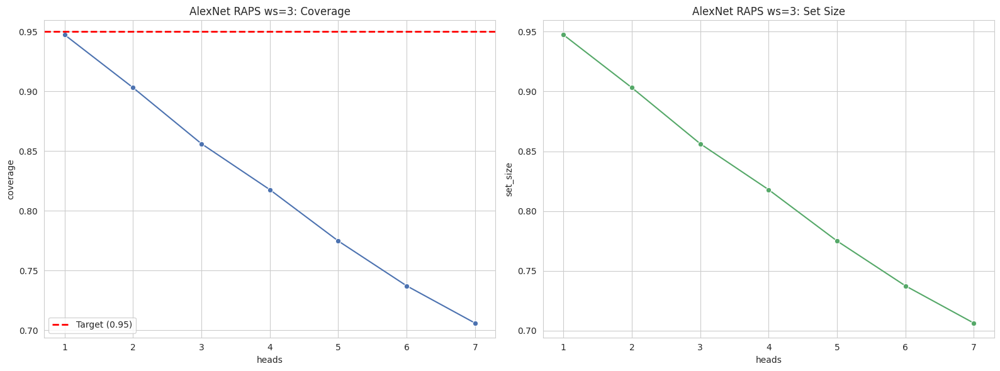

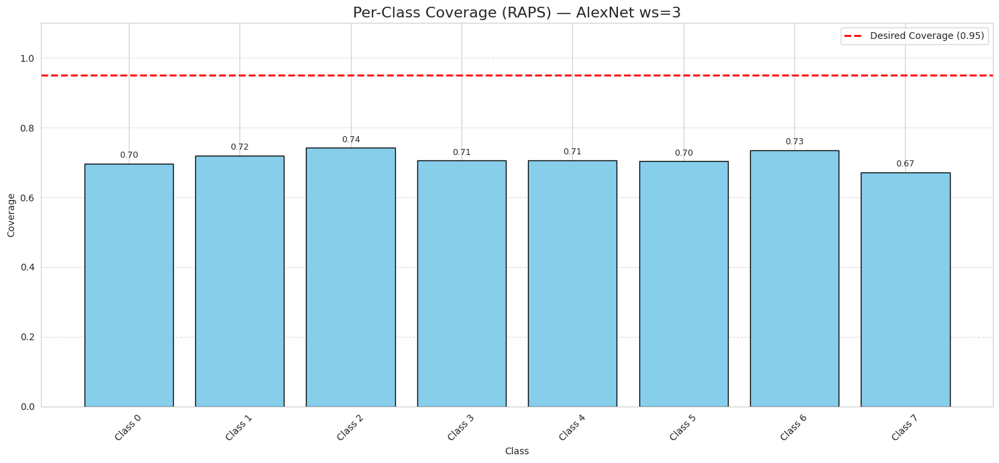

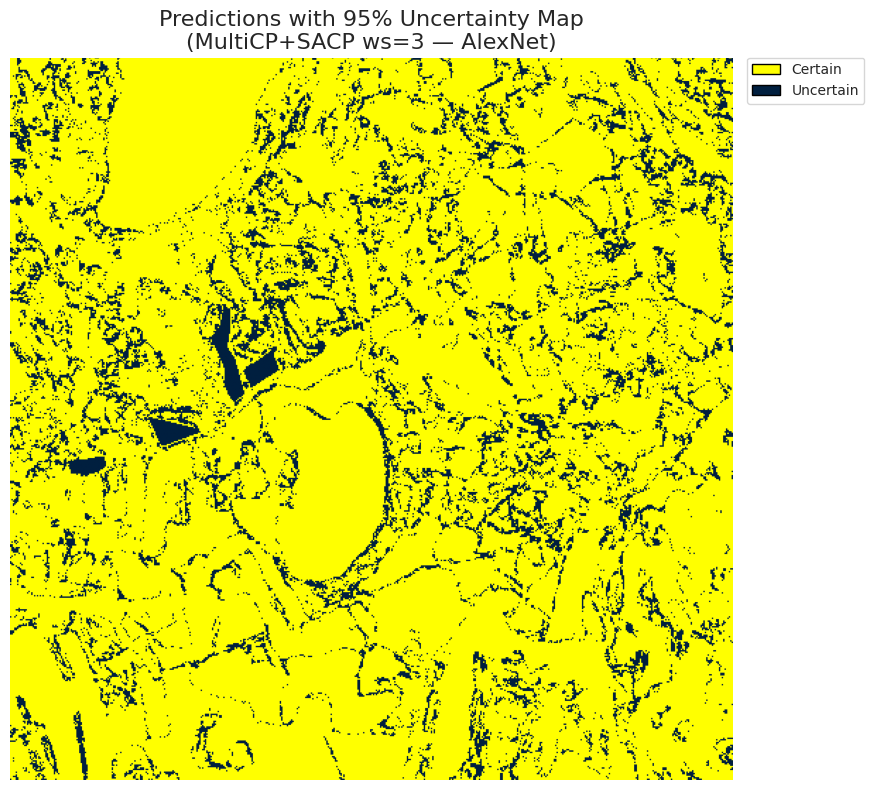

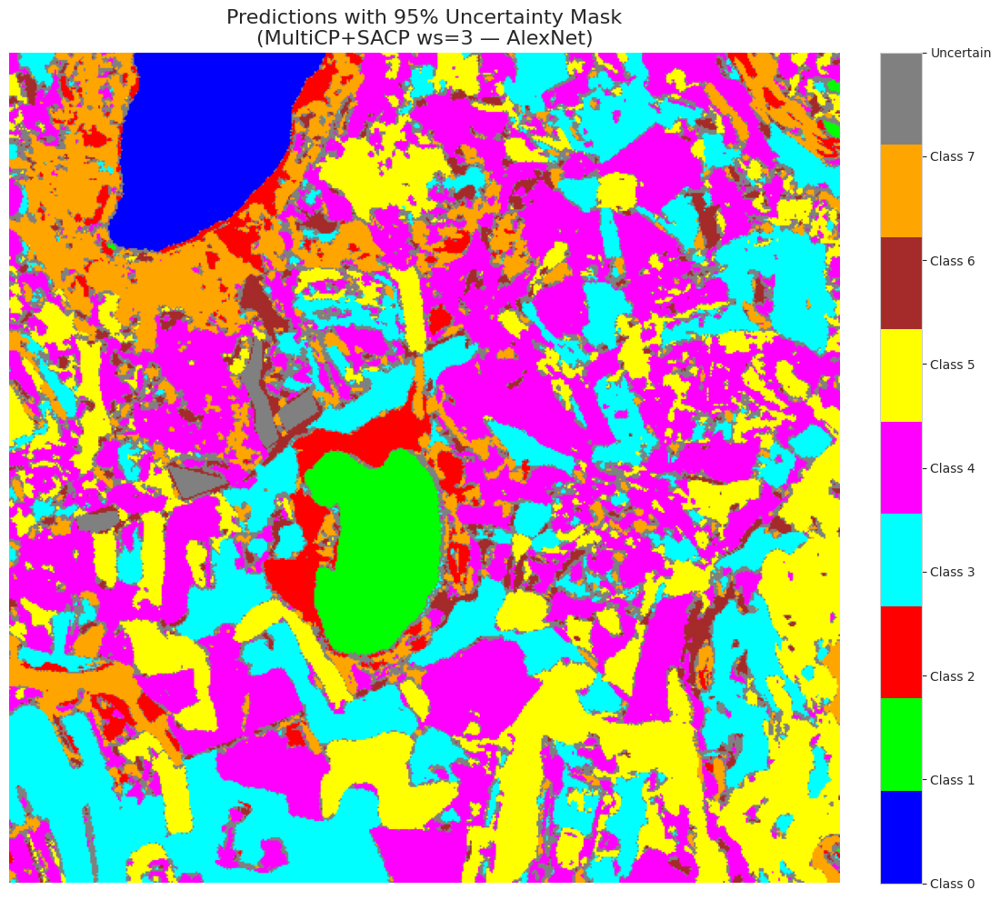

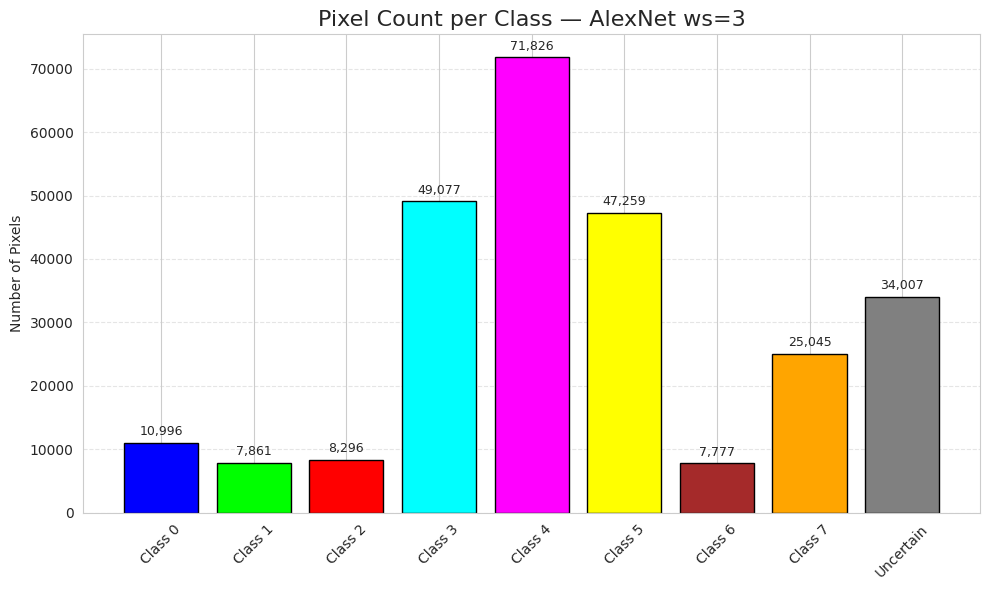

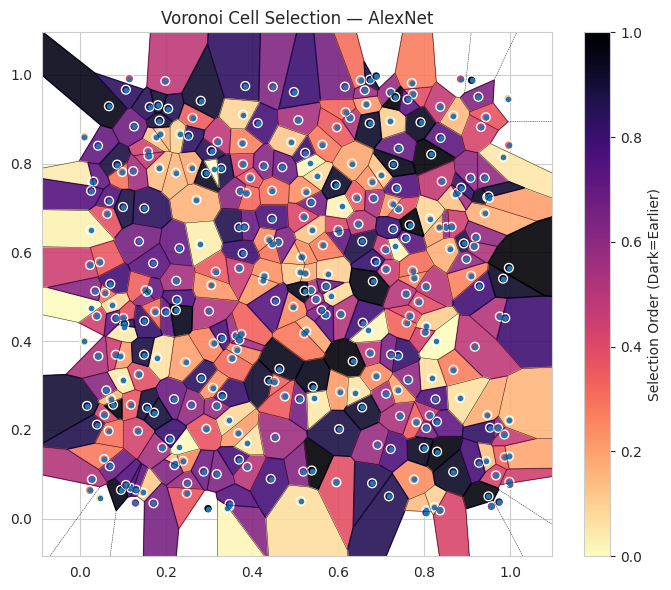

  Scoring: SAPS
  Generating full-scene map for AlexNet ...


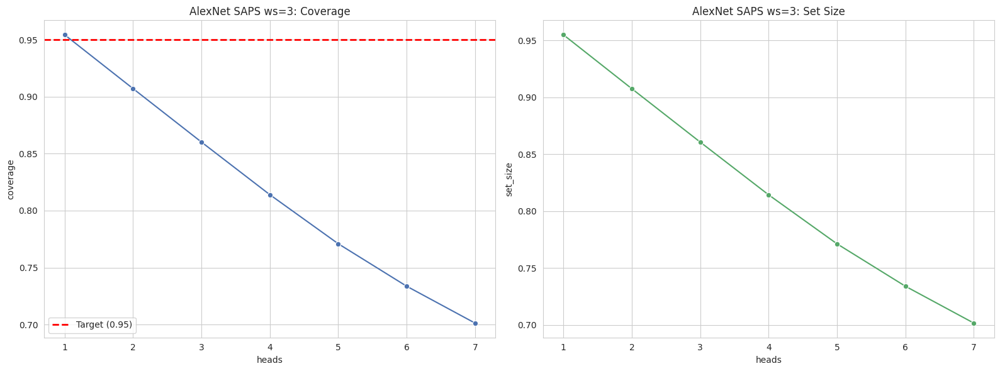

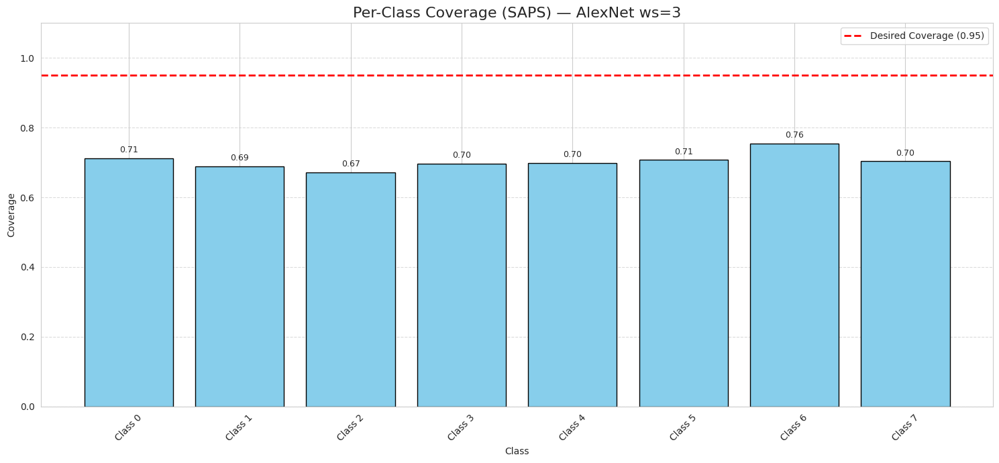

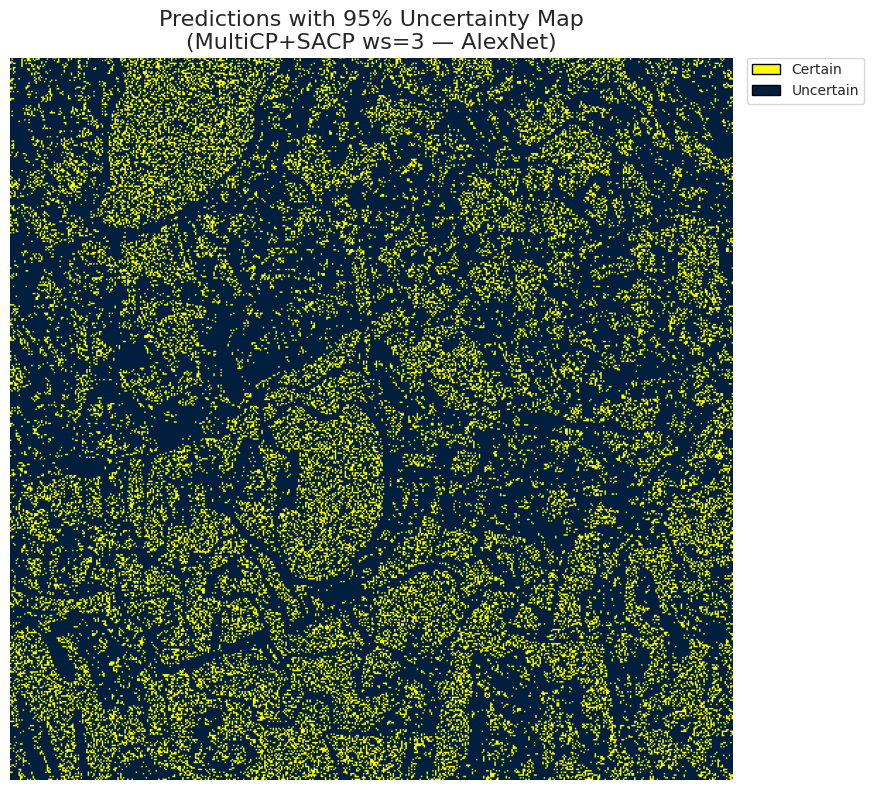

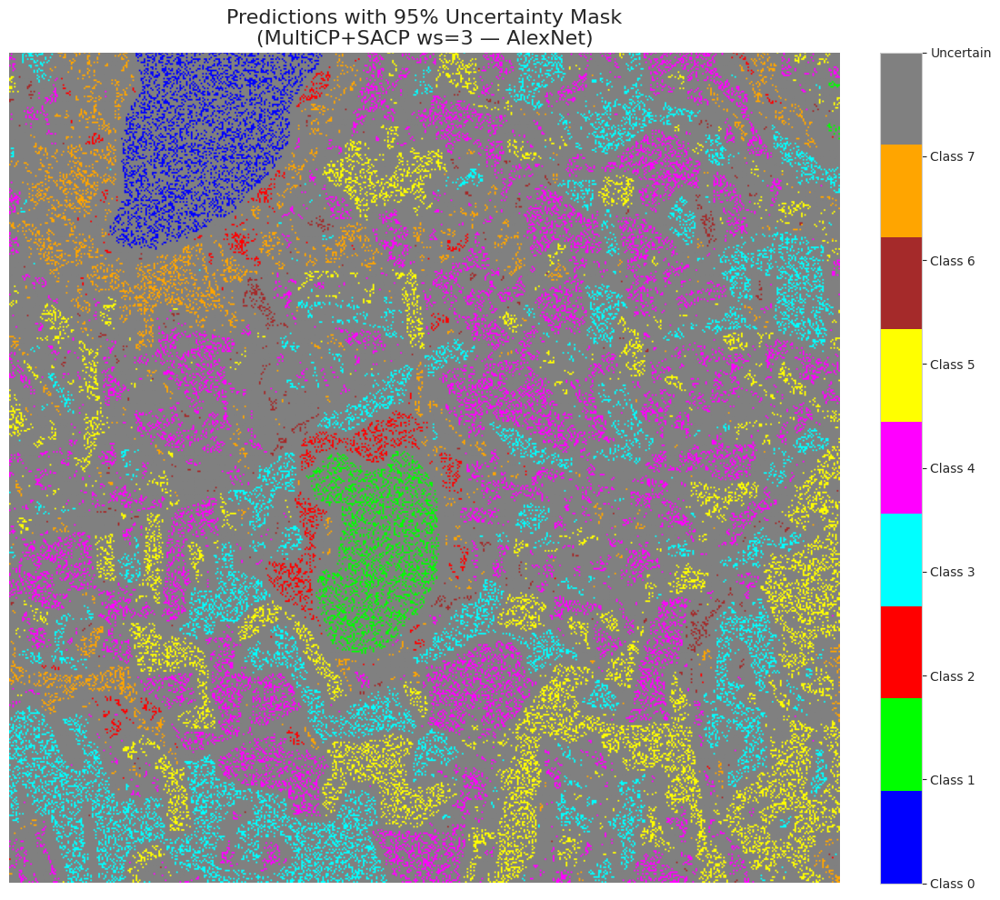

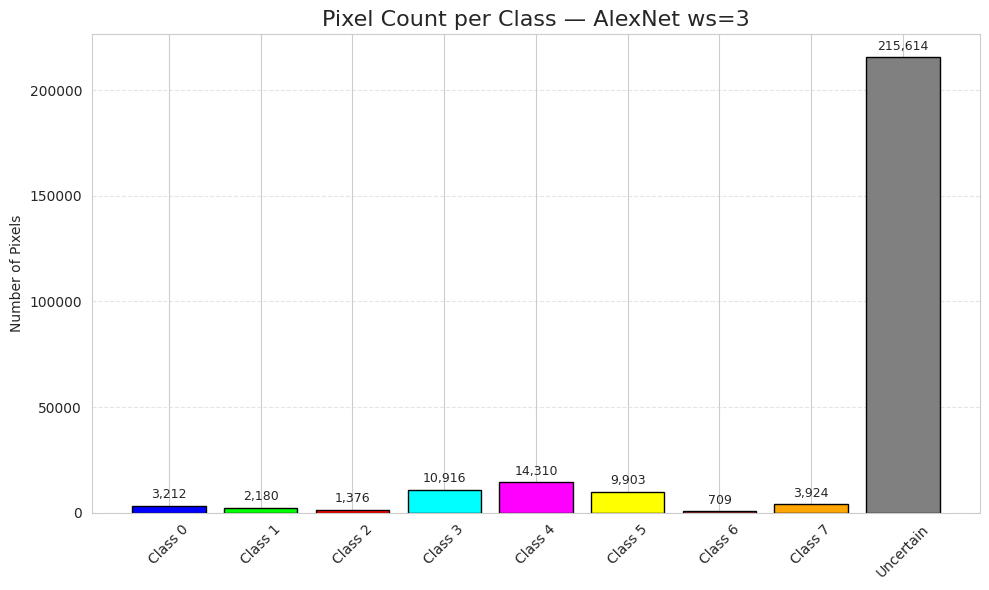

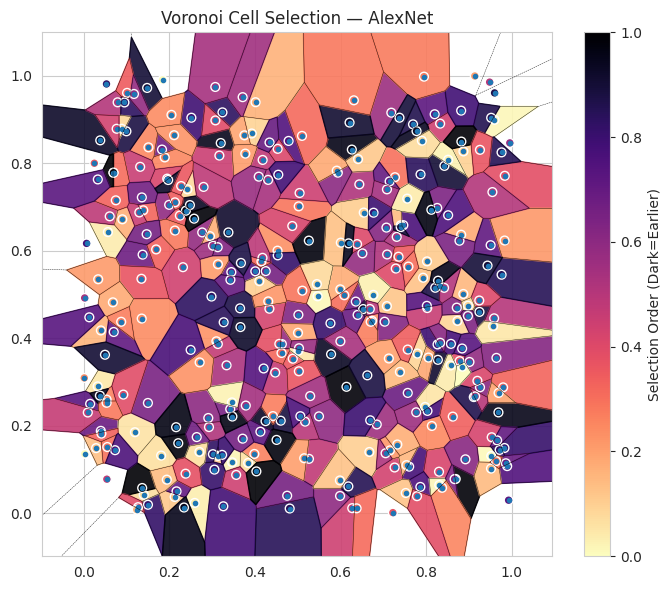

Saved: /kaggle/working/window_3/multicp_sacp_ws3_all_models.xlsx

#################################################################
  WINDOW SIZE = 5
#################################################################

==================== AlexNet (ws=5) ====================
  Scoring: RAPS
  Generating full-scene map for AlexNet ...


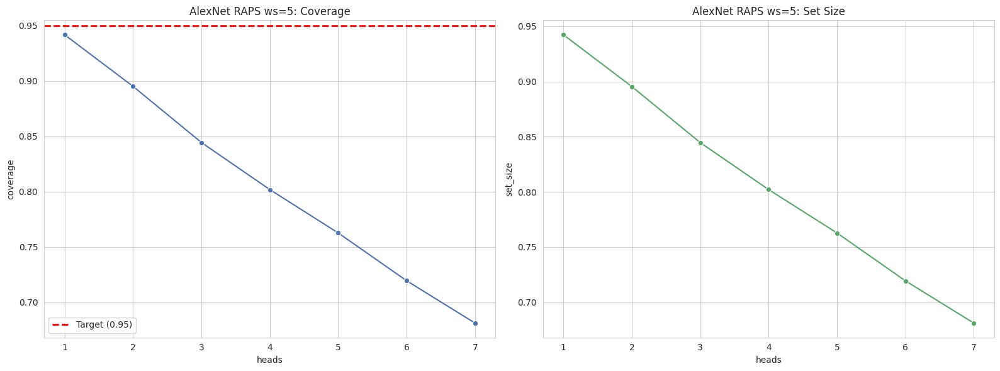

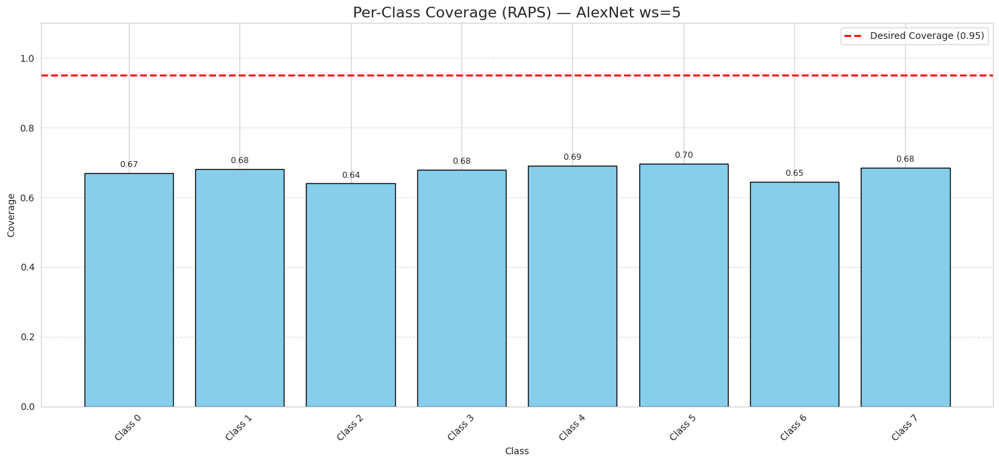

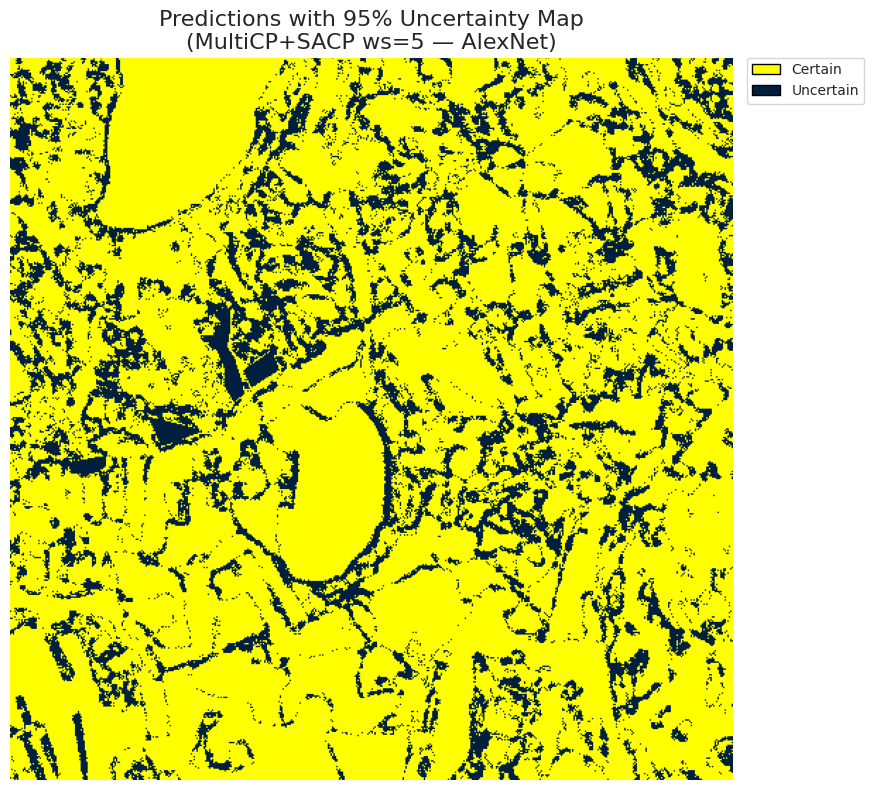

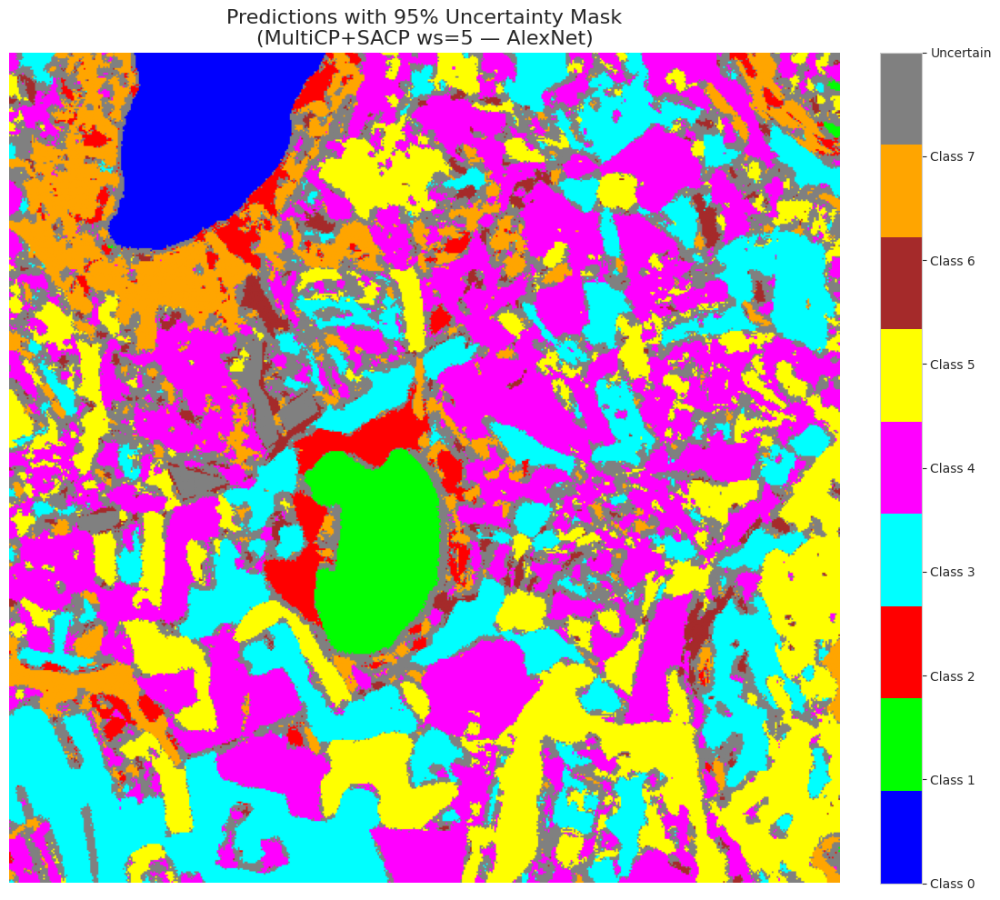

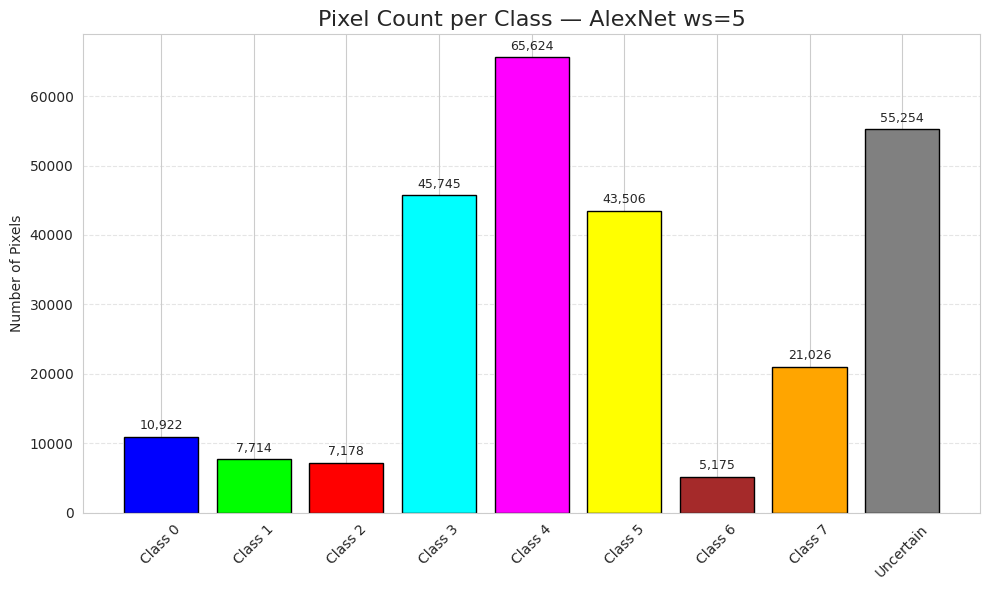

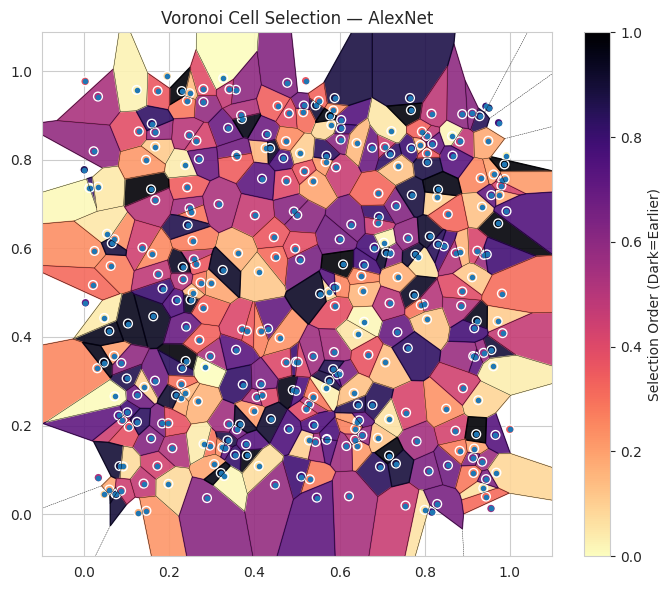

  Scoring: SAPS
  Generating full-scene map for AlexNet ...


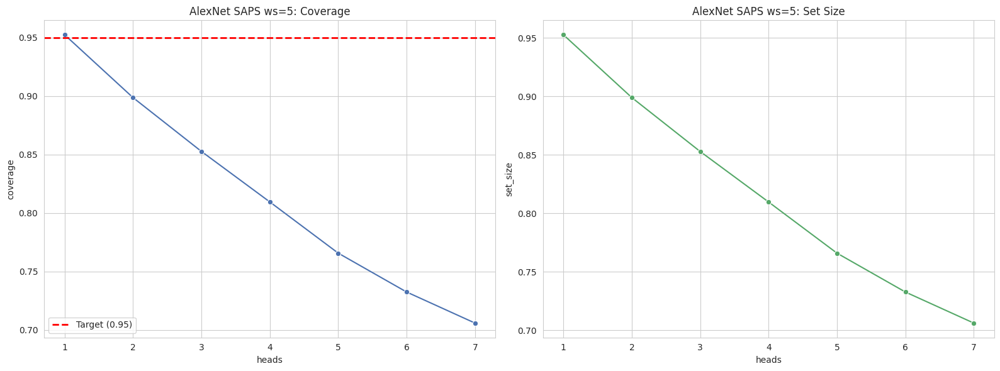

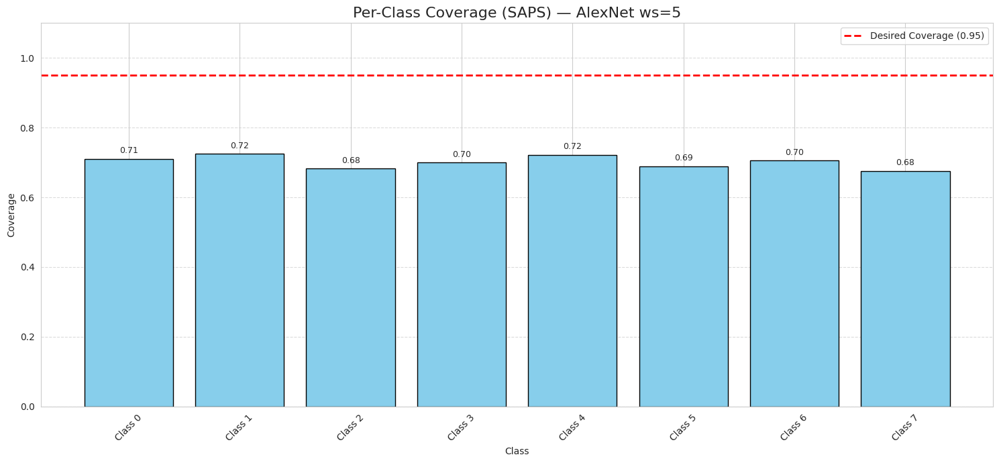

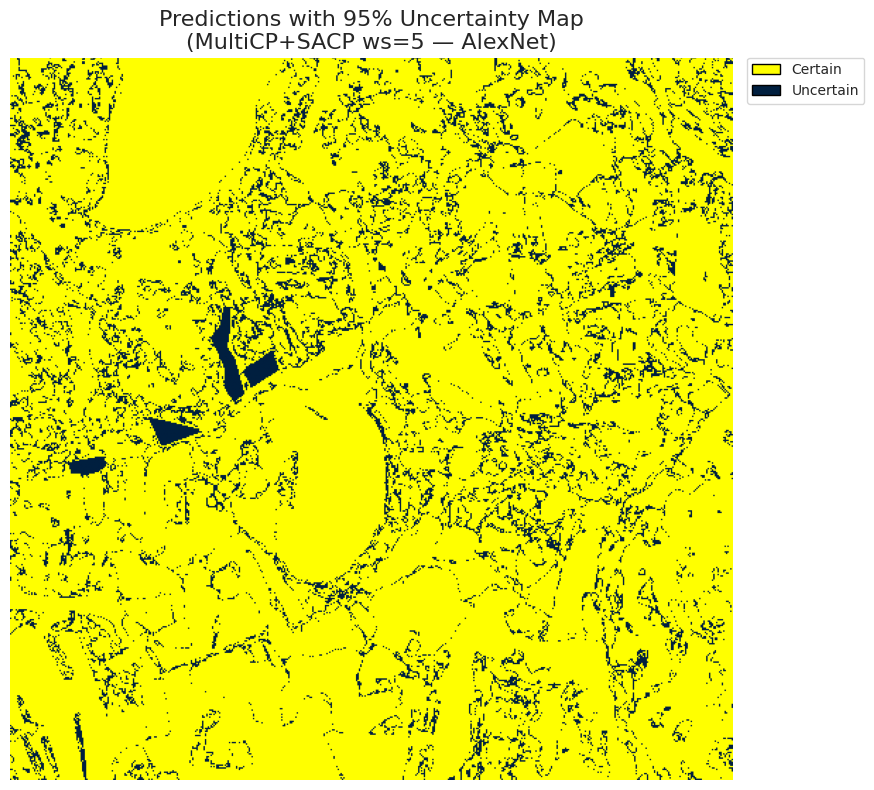

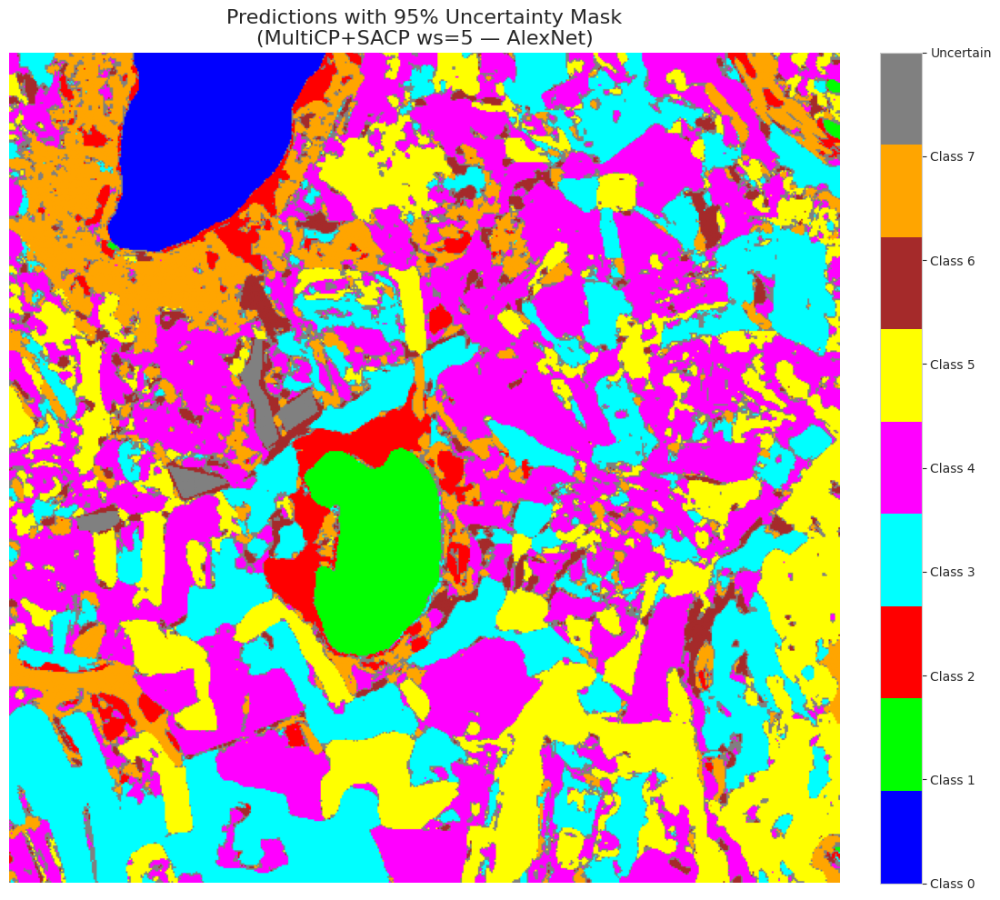

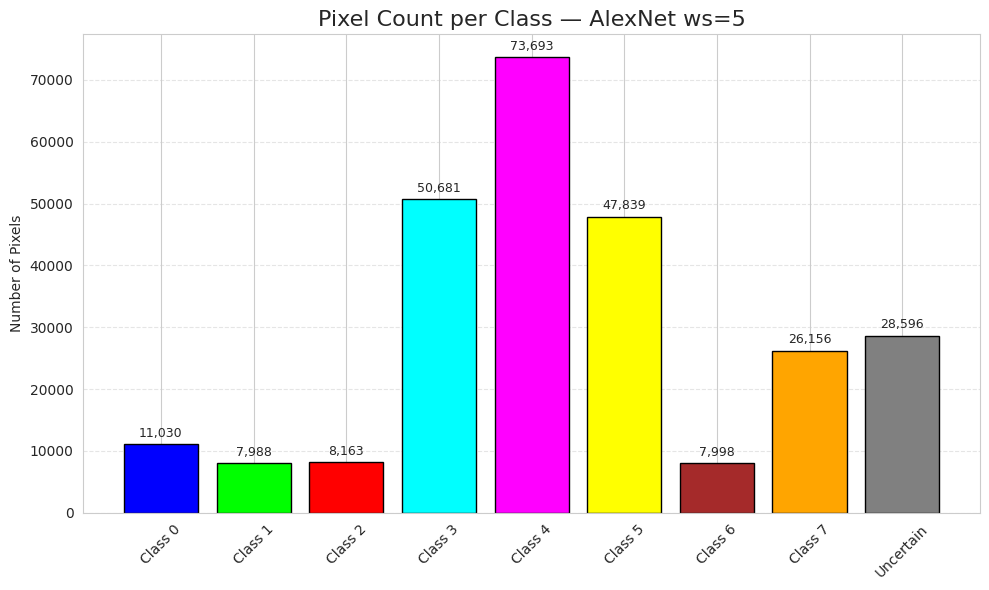

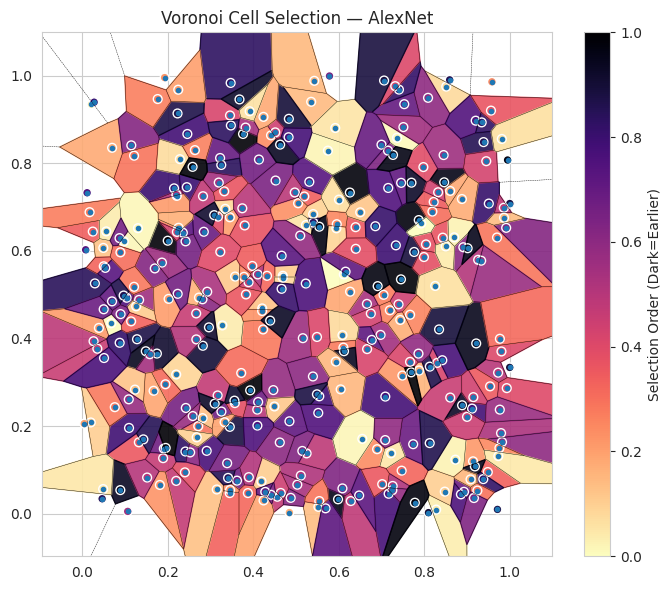

Saved: /kaggle/working/window_5/multicp_sacp_ws5_all_models.xlsx

#################################################################
  WINDOW SIZE = 7
#################################################################

==================== AlexNet (ws=7) ====================
  Scoring: RAPS
  Generating full-scene map for AlexNet ...


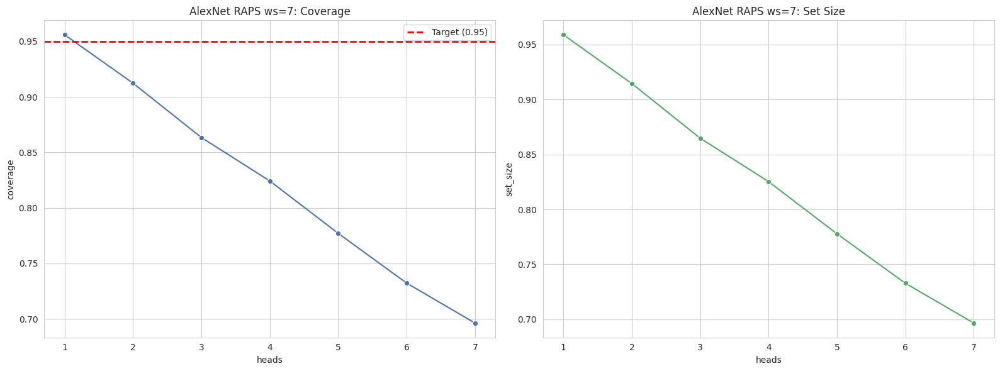

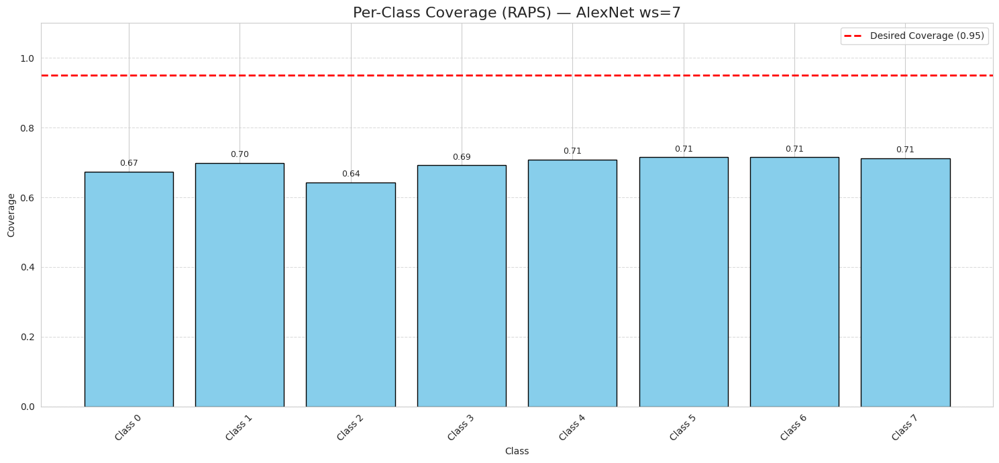

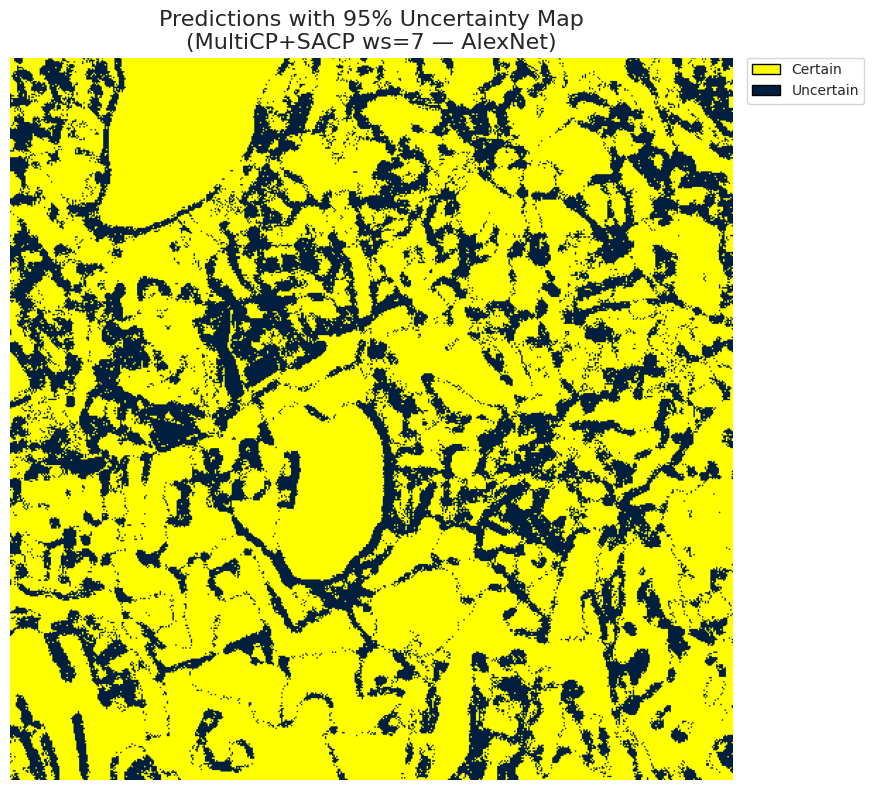

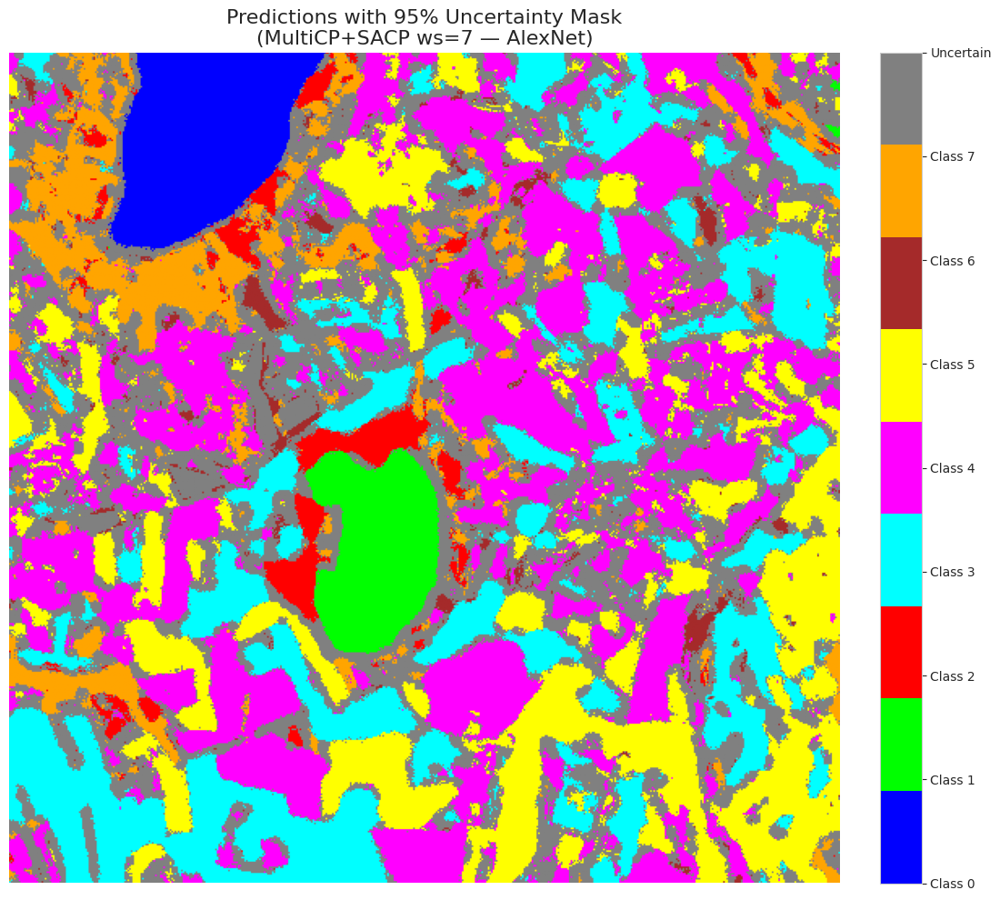

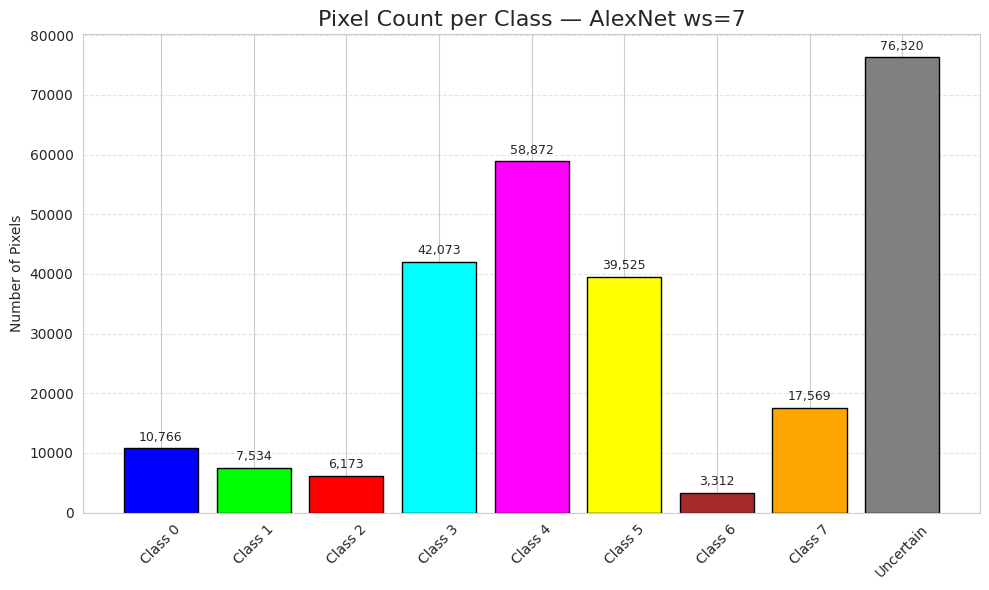

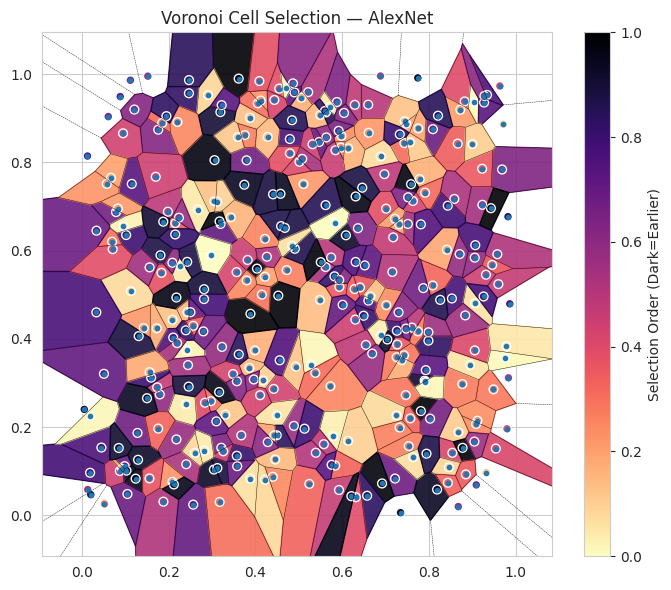

  Scoring: SAPS
  Generating full-scene map for AlexNet ...


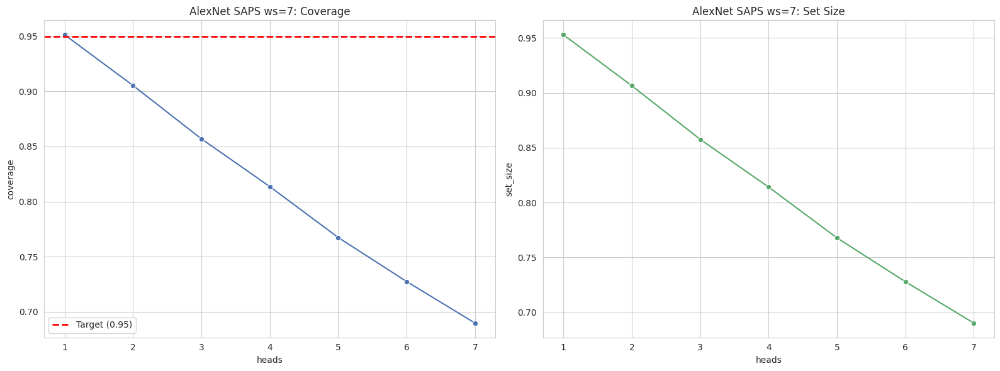

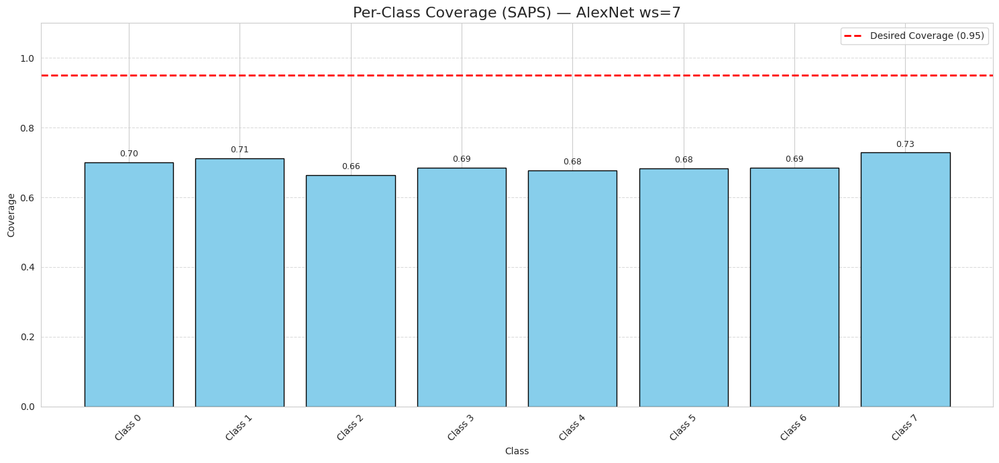

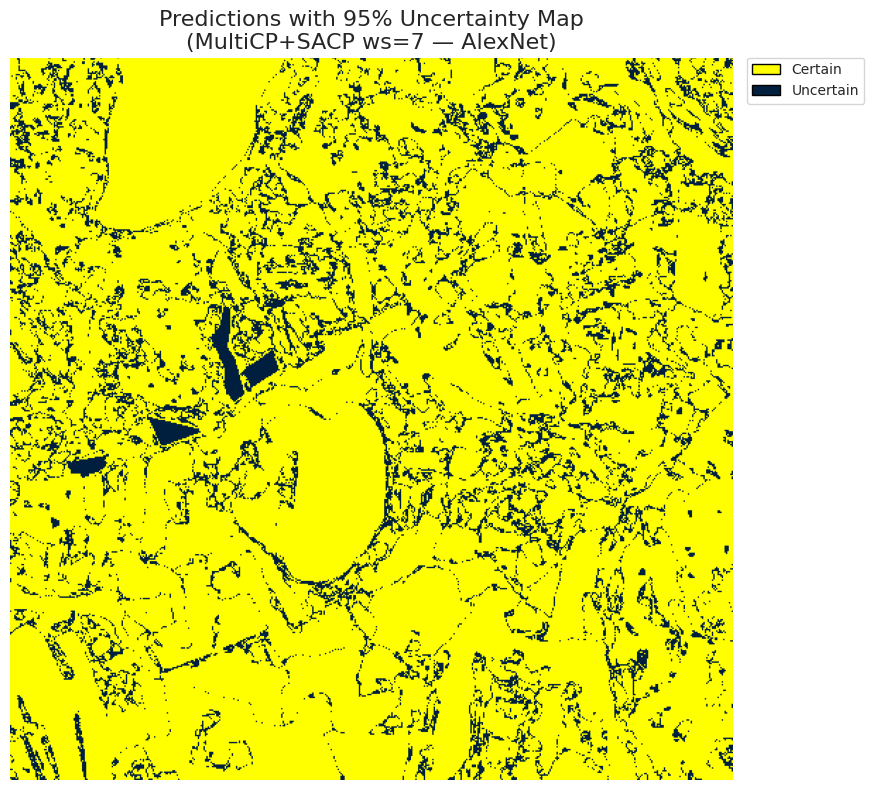

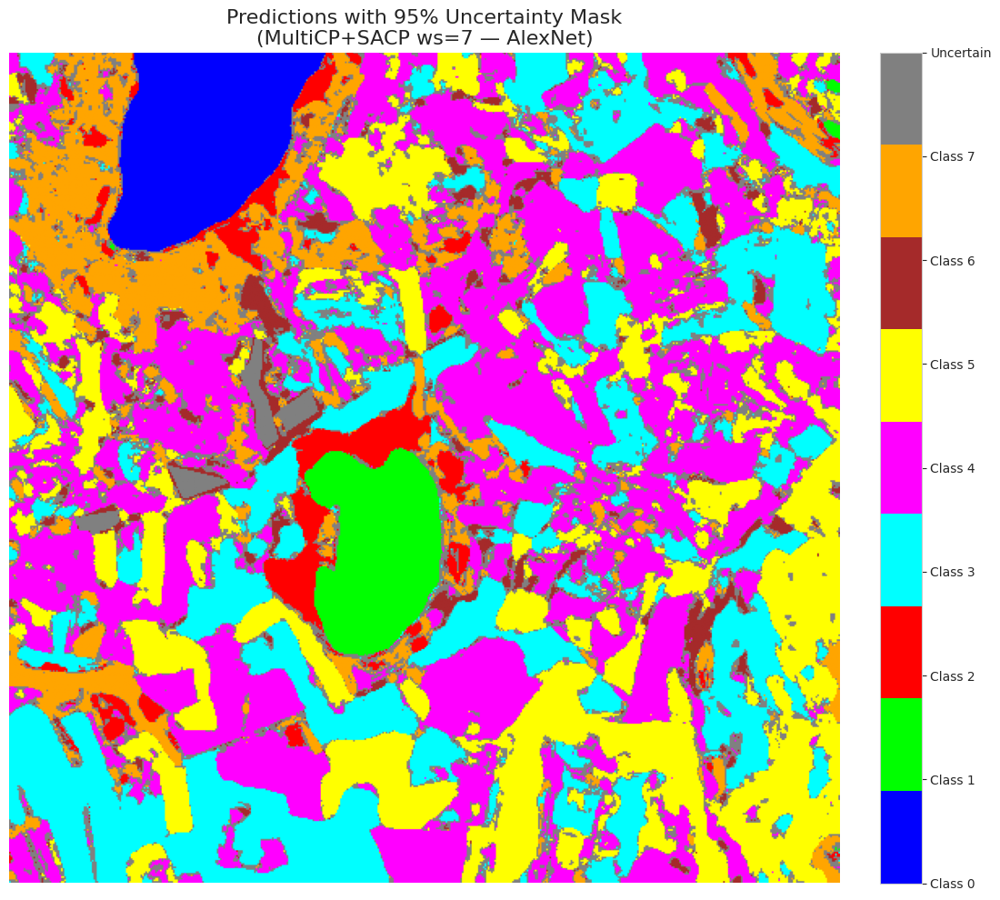

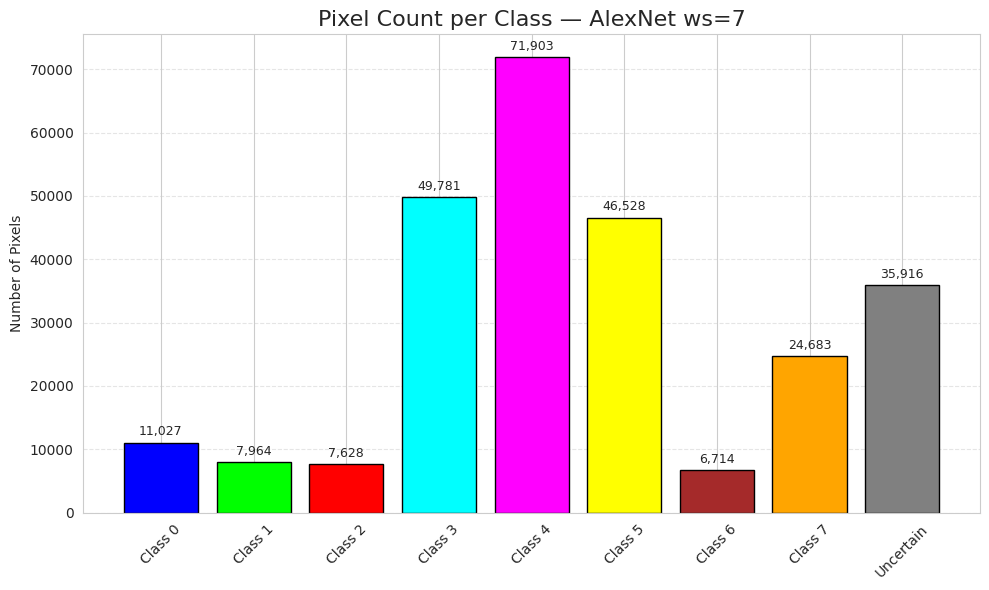

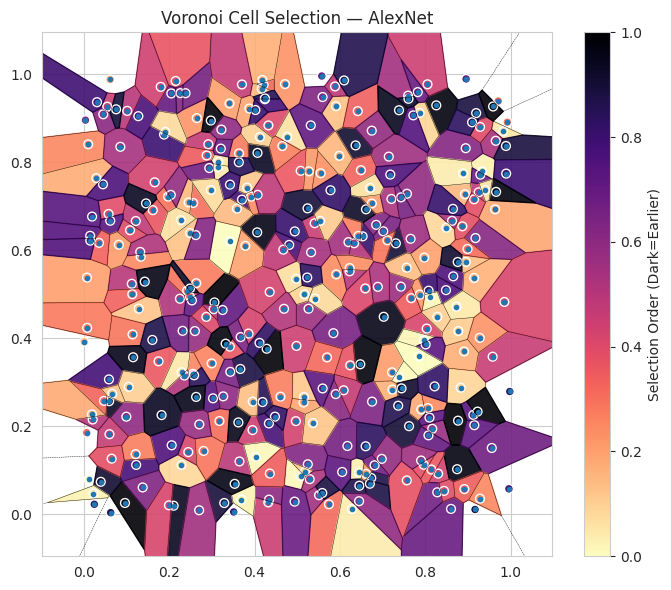

Saved: /kaggle/working/window_7/multicp_sacp_ws7_all_models.xlsx

#################################################################
  WINDOW SIZE = 9
#################################################################

==================== AlexNet (ws=9) ====================
  Scoring: RAPS
  Generating full-scene map for AlexNet ...


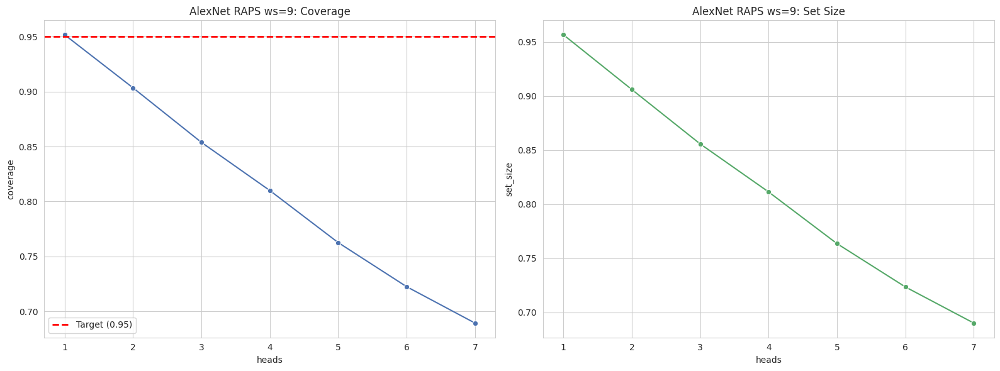

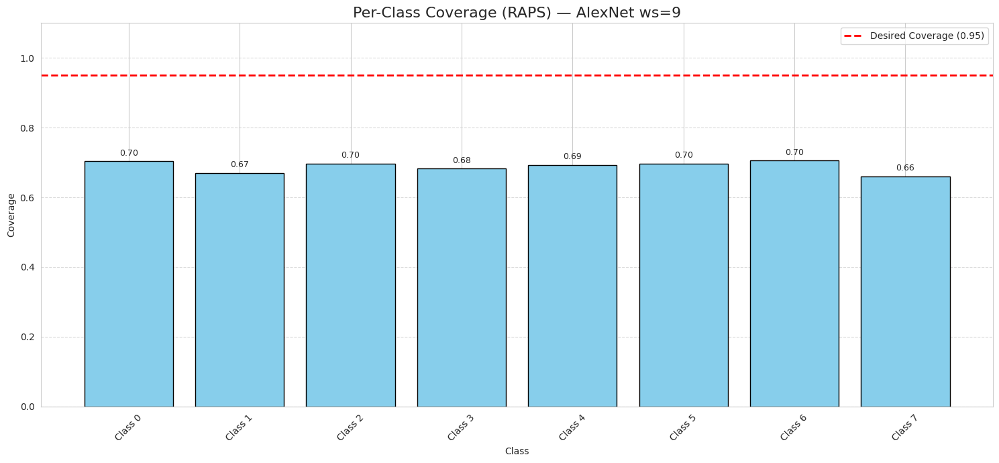

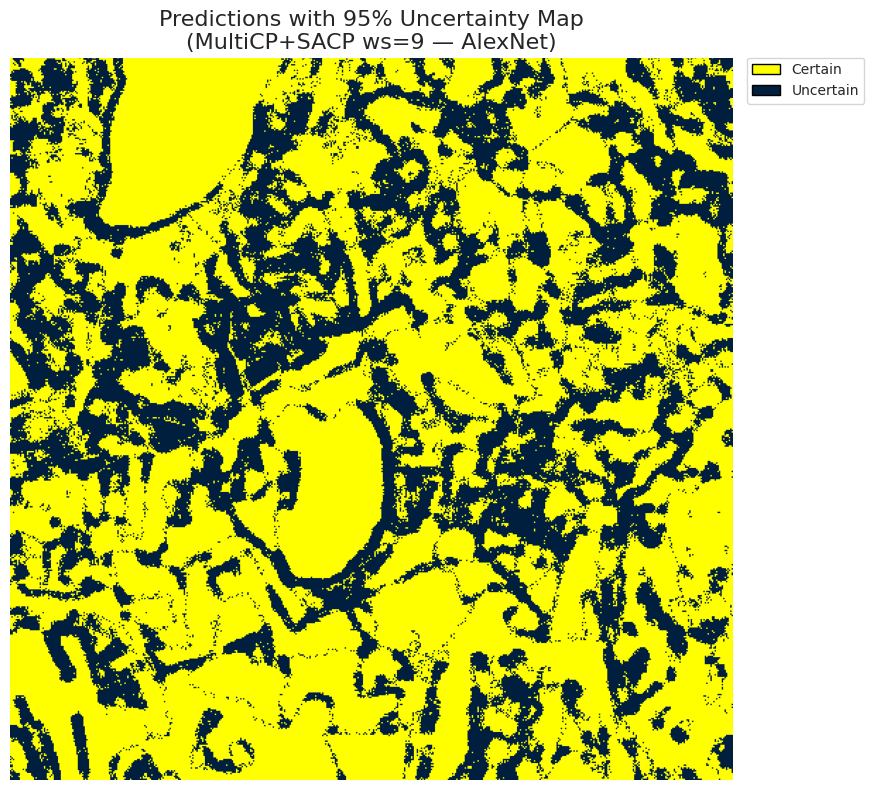

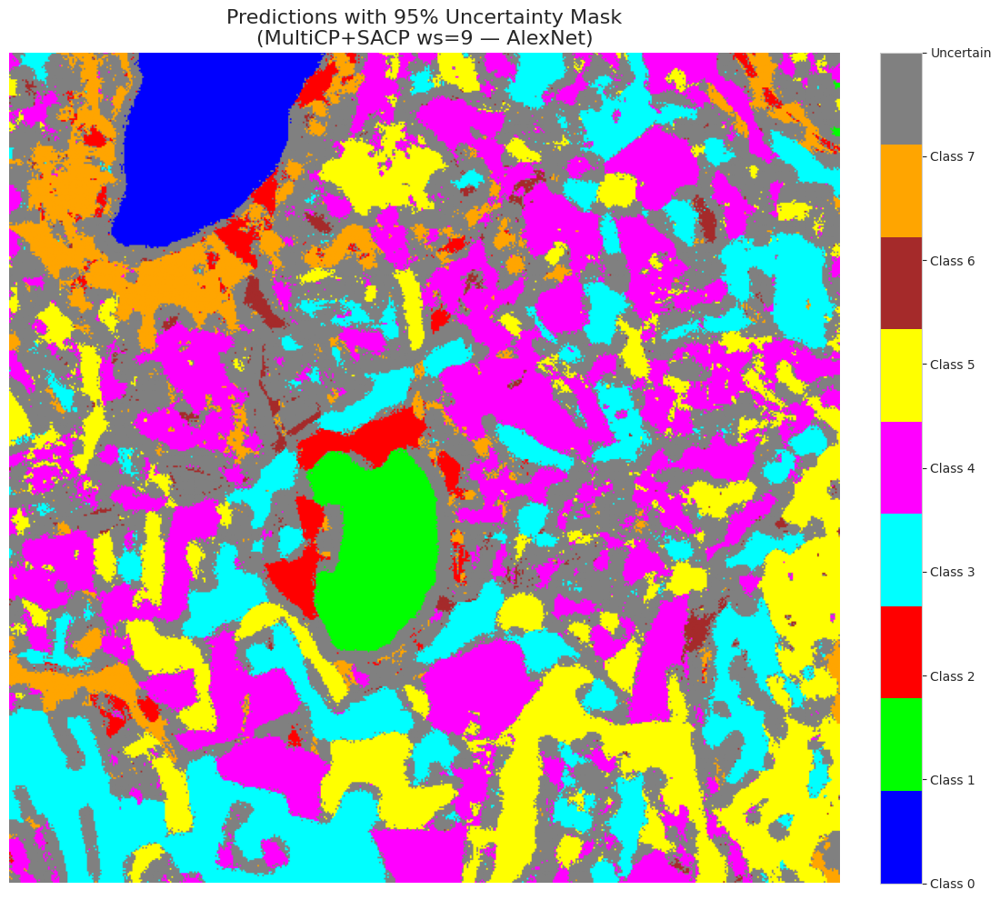

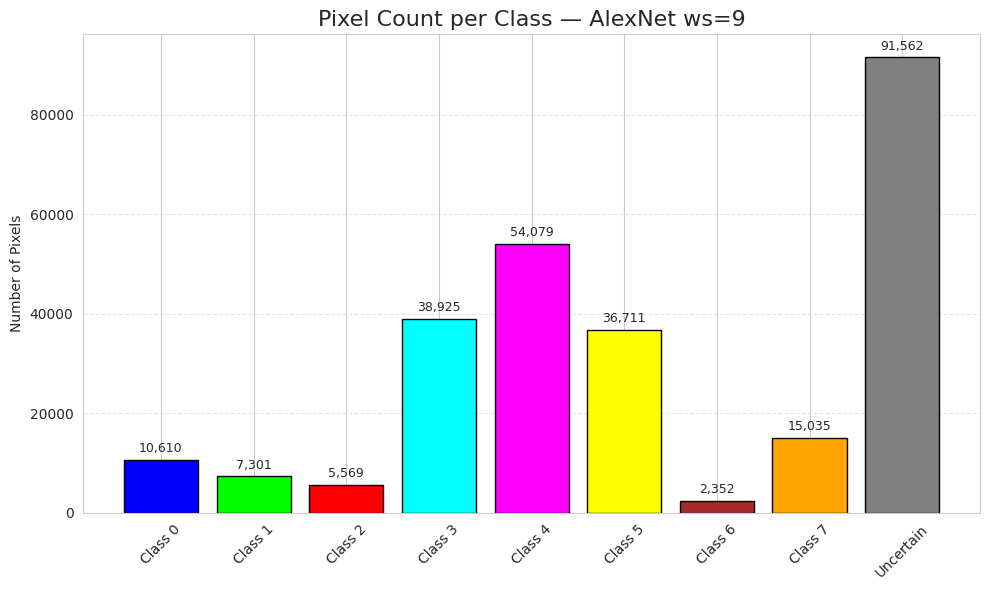

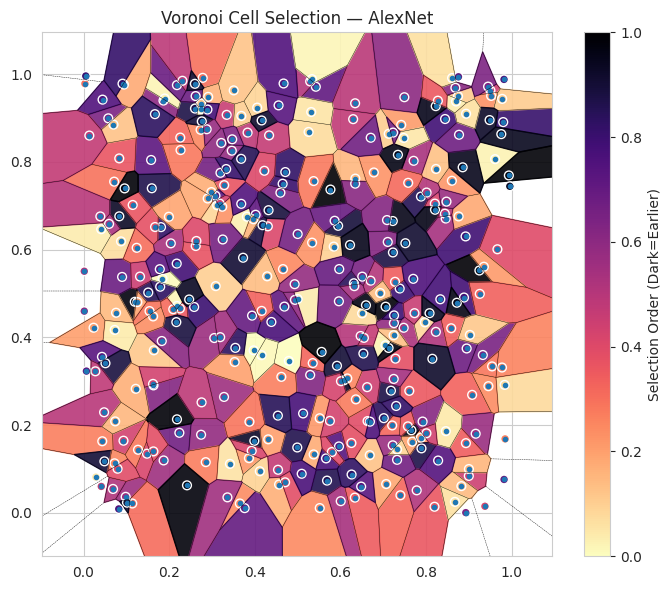

  Scoring: SAPS
  Generating full-scene map for AlexNet ...


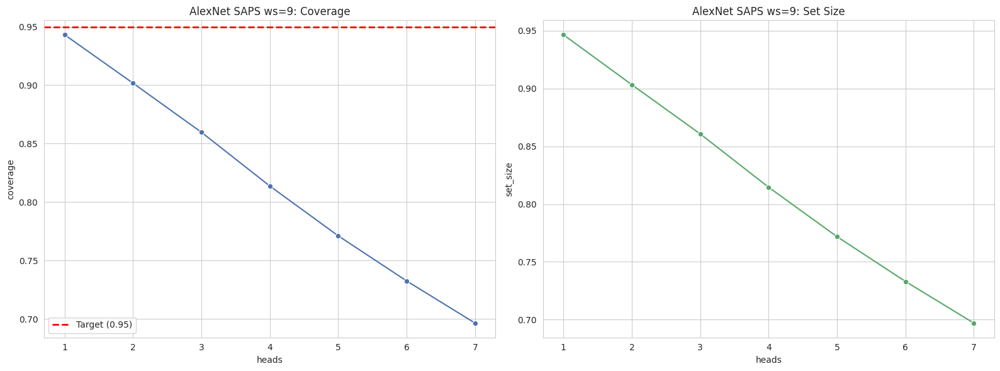

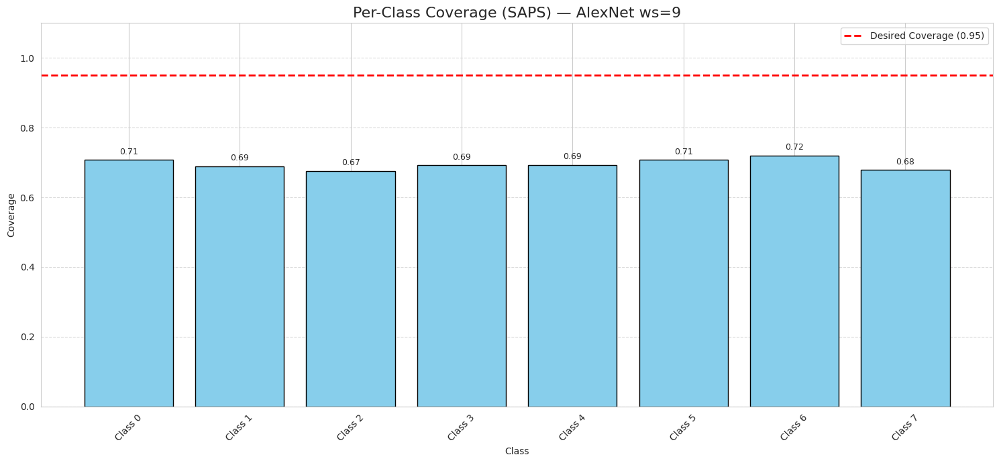

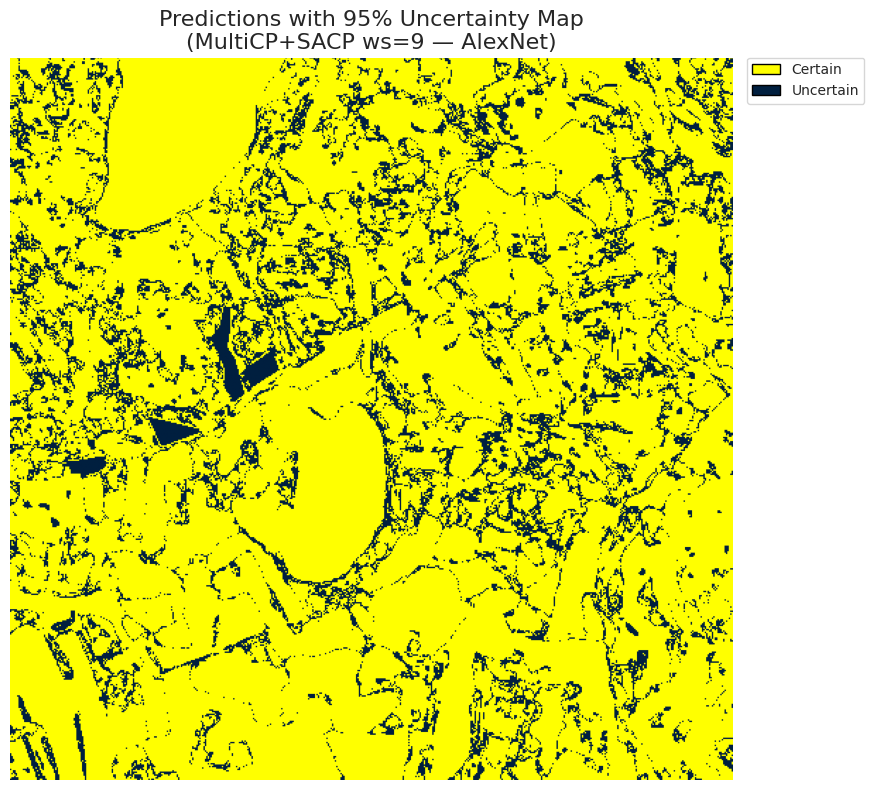

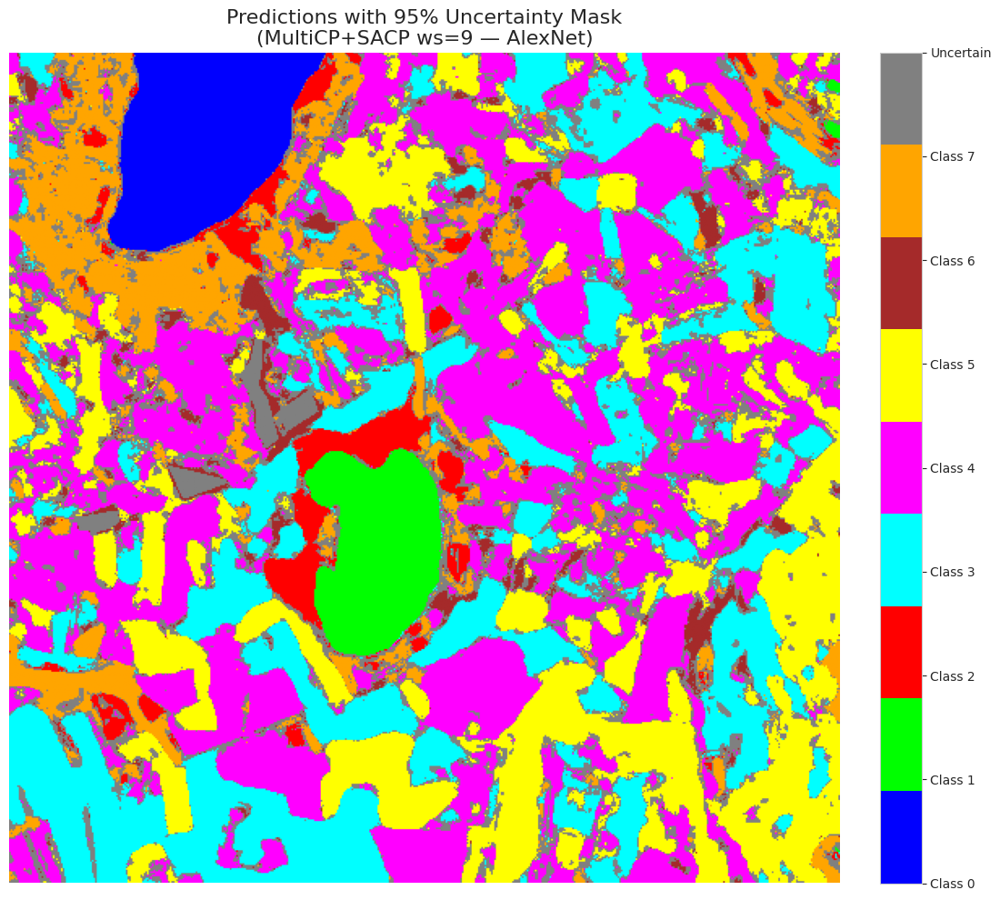

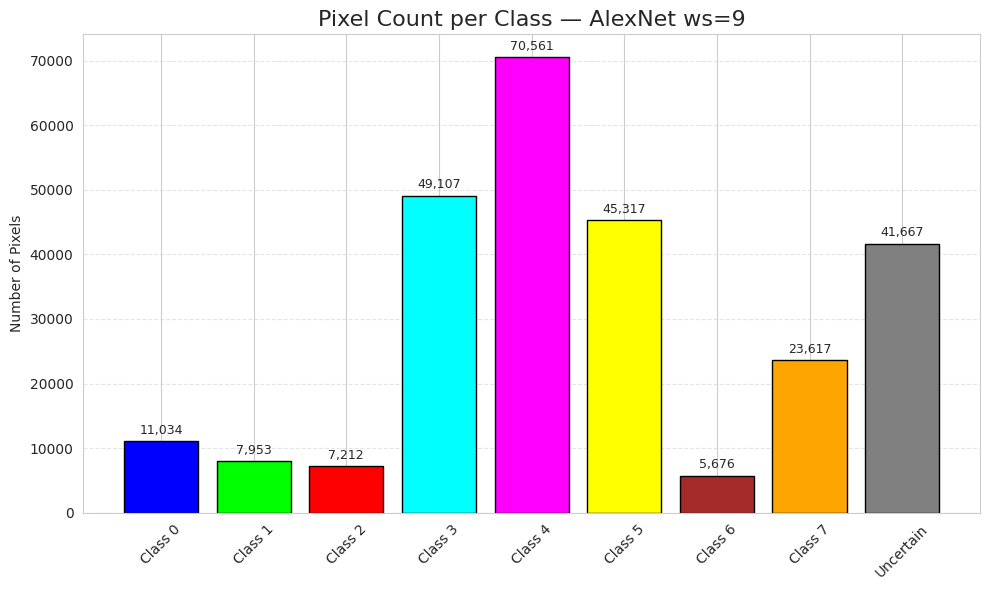

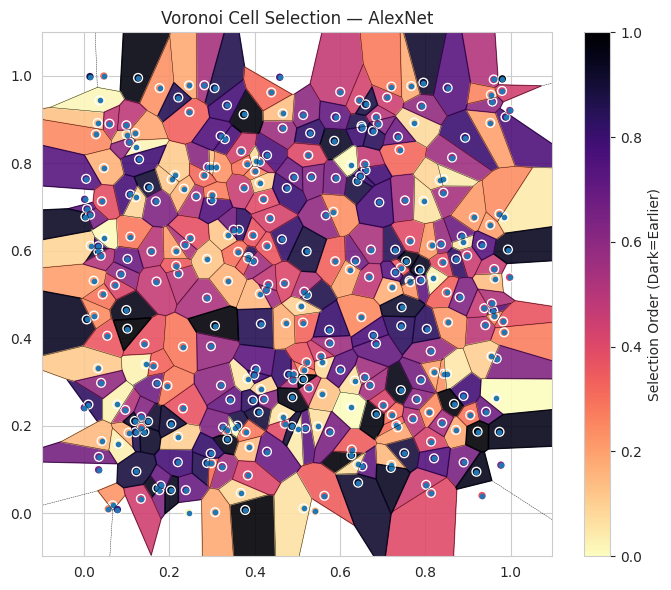

Saved: /kaggle/working/window_9/multicp_sacp_ws9_all_models.xlsx

✓ All window sizes complete.


In [20]:
all_windows_summaries = []
all_windows_per_class = []

for ws in SACP_WINDOW_SIZES:
    print(f"\n{'#'*65}")
    print(f"  WINDOW SIZE = {ws}")
    print(f"{'#'*65}")

    ws_dir = OUTPUT_DIR / f'window_{ws}'
    ws_dir.mkdir(parents=True, exist_ok=True)

    neighbors     = build_neighbour_offsets(ws)
    workbook_path = ws_dir / f'multicp_sacp_ws{ws}_all_models.xlsx'
    wb            = ensure_workbook(workbook_path)
    # Clear any sheets except Summary before repopulating
    for sheet in list(wb.sheetnames)[1:]:
        del wb[sheet]

    summary_rows     = []
    per_class_rows   = []
    used_sheet_names = set(wb.sheetnames)

    for model_key, model in models.items():
        model_name = MODEL_NAME_MAP.get(model_key, model_key)

        print(f"\n{'='*20} {model_name} (ws={ws}) {'='*20}")
        cal_output  = get_multihead_outputs(model, x_cal,  BATCH_SIZE)
        eval_output = get_multihead_outputs(model, x_eval, BATCH_SIZE)

        for scoring_method in SCORING_METHODS:
            print(f"  Scoring: {scoring_method}")
            t0 = time.perf_counter()

            # ── Fused head sweep ──────────────────────────────────────────────
            head_df, bundle = compute_head_sweep_fused(
                cal_output, eval_output,
                y_cal.astype(np.int32), y_eval.astype(np.int32),
                coords_cal, coords_eval,
                scoring_method=scoring_method,
                window_size=ws,
                lambda_=SACP_LAMBDA,
                k_iters=SACP_K,
            )
            config, Dc, Dt, Rc, Rt, pred_sets = bundle

            class_cov_df = per_class_coverage_df_fused(
                pred_sets, y_eval.astype(np.int32), num_classes)

            # ── Full-scene binary map ─────────────────────────────────────────
            print(f'  Generating full-scene map for {model_name} ...')
            binary_outputs = build_binary_uncertainty_outputs_fused(
                model, padded_x, y_img,
                config, Dc, Dt, Rc, Rt,
                neighbors=neighbors, lambda_=SACP_LAMBDA, k_iters=SACP_K,
            )
            runtime = time.perf_counter() - t0

            # ── Figures ───────────────────────────────────────────────────────
            sweep_fig  = head_sweep_figure(head_df, model_name, scoring_method, ws)
            class_fig  = per_class_figure(class_cov_df, model_name, scoring_method, ws)
            binary_fig = binary_uncertainty_figure(
                binary_outputs['binary_uncertainty_map'], model_name, ws)
            pred_fig   = prediction_map_figure(binary_outputs['display_map'], model_name, ws)
            counts_fig = pixel_count_figure(
                binary_outputs['class_pixel_counts'], model_name, ws)
            D_i_order  = np.argsort(-np.mean(Dc, axis=1))
            vor_fig, vor_df = visualize_cell_selection(Dc, Dt, D_i_order, model_name)

            # ── Assemble summary row ──────────────────────────────────────────
            summary = {
                'model_key'           : model_key,
                'model_name'          : model_name,
                'scoring_method'      : scoring_method,
                'window_size'         : int(ws),
                'lambda'              : float(SACP_LAMBDA),
                'k_iters'             : int(SACP_K),
                'empirical_coverage'  : float(head_df.iloc[-1]['coverage']),
                'avg_set_size'        : float(head_df.iloc[-1]['set_size']),
                'scene_coverage'      : float(binary_outputs['coverage']),
                'scene_avg_set_size'  : float(binary_outputs['mean_set_size']),
                'uncertain_pixel_rate': float(binary_outputs['binary_uncertainty_map'].mean()),
                'mean_per_class_cov'  : float(class_cov_df['class_coverage'].mean(skipna=True)),
                'runtime_sec'         : float(runtime),
                'alpha'               : float(ALPHA),
            }
            summary_rows.append(summary)
            per_class_rows.append(
                class_cov_df.assign(
                    model_name=model_name,
                    scoring_method=scoring_method,
                    window_size=ws)
            )

            # ── Write Excel sheet ─────────────────────────────────────────────
            sheet_name = make_sheet_name(
                f'{model_name[:8]}_{scoring_method}_ws{ws}', used_sheet_names)
            ws_xl = wb.create_sheet(title=sheet_name)

            # Summary metadata at top-left (rows 1–14)
            for idx, (k_s, v) in enumerate(summary.items(), start=1):
                ws_xl.cell(row=idx, column=1, value=k_s)
                ws_xl.cell(row=idx, column=2, value=v)

            write_df(ws_xl, head_df,      start_row=18, start_col=1)
            write_df(ws_xl, class_cov_df, start_row=18, start_col=6)
            write_df(ws_xl, pd.DataFrame({
                'Class' : [f'Class {i}' for i in range(NUM_CLASSES)] + ['Uncertain'],
                'Pixels': binary_outputs['class_pixel_counts'],
            }), start_row=18, start_col=10)
            write_df(ws_xl, vor_df, start_row=50, start_col=1)

            for anchor, fig in [('N2',  sweep_fig), ('N28', class_fig),
                                 ('N54', binary_fig), ('V54', pred_fig),
                                 ('N80', counts_fig), ('V2',  vor_fig)]:
                add_image(ws_xl, fig, anchor)

            autosize_columns(ws_xl)

    # ── Per-window DataFrames ──────────────────────────────────────────────────
    ws_summary_df   = pd.DataFrame(summary_rows).query(f'window_size == {ws}')
    ws_per_class_df = pd.concat(
        [r for r in per_class_rows if r['window_size'].iloc[0] == ws],
        ignore_index=True)

    # ── Comparison sheet ───────────────────────────────────────────────────────
    compare_cols  = ['model_name', 'scoring_method', 'window_size',
                     'empirical_coverage', 'avg_set_size', 'uncertain_pixel_rate',
                     'mean_per_class_cov', 'runtime_sec']
    compare_df    = ws_summary_df[[c for c in compare_cols if c in ws_summary_df.columns]]
    compare_sheet = make_sheet_name(f'Compare_ws{ws}', used_sheet_names)
    compare_ws    = wb.create_sheet(title=compare_sheet)
    write_df(compare_ws, compare_df); autosize_columns(compare_ws)

    # ── Run config sheet ───────────────────────────────────────────────────────
    cfg_sheet = make_sheet_name(f'RunConfig_ws{ws}', used_sheet_names)
    cfg_ws    = wb.create_sheet(title=cfg_sheet)
    write_df(cfg_ws, pd.DataFrame([{
        'window_size': ws, 'alpha': ALPHA, 'lambda': SACP_LAMBDA,
        'k_iters': SACP_K, 'scoring_methods': str(SCORING_METHODS),
    }]))

    # Finalise Summary sheet with all rows collected so far
    all_summary_so_far = pd.DataFrame(summary_rows)
    summary_ws_xl      = wb['Summary']
    summary_ws_xl.delete_rows(1, summary_ws_xl.max_row)
    write_df(summary_ws_xl, all_summary_so_far); autosize_columns(summary_ws_xl)

    wb.save(workbook_path)
    print(f'Saved: {workbook_path}')

    # Per-window CSVs
    ws_summary_df.to_csv(ws_dir / f'summary_ws{ws}.csv', index=False)
    ws_per_class_df.to_csv(ws_dir / f'per_class_ws{ws}.csv', index=False)

    all_windows_summaries.append(ws_summary_df)
    all_windows_per_class.append(ws_per_class_df)

print("\n✓ All window sizes complete.")

# 9.0 — Combined Cross-Window Summary

Assembles a single combined summary DataFrame, saves the two top-level CSVs, and produces cross-window comparison line plots (coverage, set size, mean per-class coverage) for each scoring method.

Saved combined summary csv  : /kaggle/working/combined_summary_all_windows.csv
Saved combined per-class csv: /kaggle/working/combined_per_class_all_windows.csv


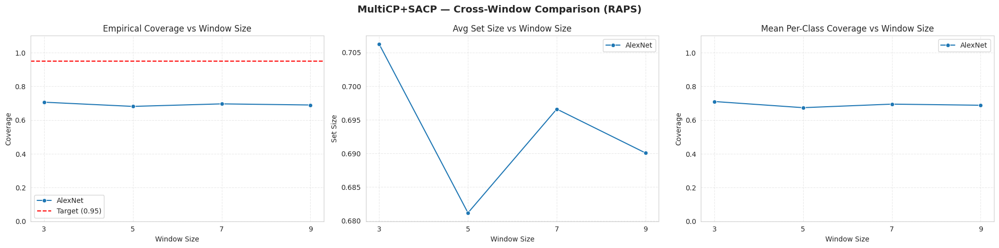

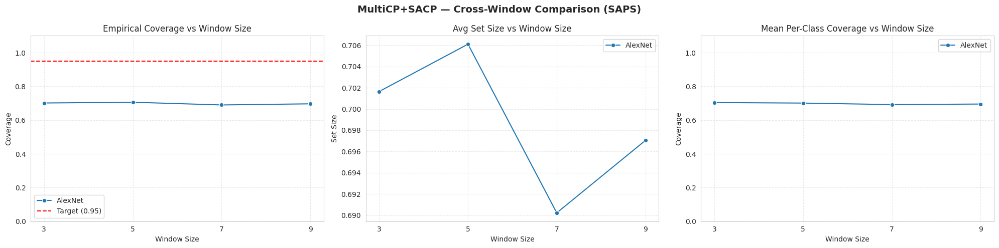

,model_key,model_name,scoring_method,window_size,lambda,k_iters,empirical_coverage,avg_set_size,scene_coverage,scene_avg_set_size,uncertain_pixel_rate,mean_per_class_cov,runtime_sec,alpha
0,AlexNet_CNN_MultiHead,AlexNet,RAPS,3,0.5,1,0.706101,0.706249,0.149967,0.954581,0.129726,0.710115,106.805305,0.05
1,AlexNet_CNN_MultiHead,AlexNet,SAPS,3,0.5,1,0.701351,0.701648,0.143715,0.896300,0.822502,0.703891,107.807828,0.05
2,AlexNet_CNN_MultiHead,AlexNet,RAPS,5,0.5,1,0.681164,0.681164,0.170102,1.095022,0.210777,0.673616,154.543496,0.05
3,AlexNet_CNN_MultiHead,AlexNet,SAPS,5,0.5,1,0.705804,0.706101,0.154155,0.969960,0.109085,0.700808,154.876752,0.05
4,AlexNet_CNN_MultiHead,AlexNet,RAPS,7,0.5,1,0.696156,0.696601,0.188458,1.231592,0.291138,0.694618,220.109553,0.05
5,AlexNet_CNN_MultiHead,AlexNet,SAPS,7,0.5,1,0.689773,0.690218,0.162415,1.020576,0.137009,0.691981,219.488983,0.05
6,AlexNet_CNN_MultiHead,AlexNet,RAPS,9,0.5,1,0.689476,0.690070,0.202302,1.330652,0.349281,0.688004,304.010406,0.05
7,AlexNet_CNN_MultiHead,AlexNet,SAPS,9,0.5,1,0.696452,0.697046,0.169050,1.060898,0.158947,0.695140,295.524336,0.05


In [21]:
combined_summary_df   = pd.concat(all_windows_summaries, ignore_index=True)
combined_per_class_df = pd.concat(all_windows_per_class, ignore_index=True)

combined_summary_df.to_csv(COMBINED_SUMMARY_CSV,  index=False)
combined_per_class_df.to_csv(COMBINED_PERCLASS_CSV, index=False)
print('Saved combined summary csv  :', COMBINED_SUMMARY_CSV)
print('Saved combined per-class csv:', COMBINED_PERCLASS_CSV)

# Cross-window comparison plots — one per scoring method
for sm in SCORING_METHODS:
    sub = combined_summary_df[combined_summary_df['scoring_method'] == sm]
    if sub.empty:
        continue
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f'MultiCP+SACP — Cross-Window Comparison ({sm})',
                  fontsize=14, fontweight='bold')

    sns.lineplot(data=sub, x='window_size', y='empirical_coverage',
                  hue='model_name', marker='o', ax=axes[0])
    axes[0].axhline(1 - ALPHA, linestyle='--', color='red', linewidth=1.5,
                    label=f'Target ({1-ALPHA:.2f})')
    axes[0].set_title('Empirical Coverage vs Window Size')
    axes[0].set_xlabel('Window Size'); axes[0].set_ylabel('Coverage')
    axes[0].set_ylim(0, 1.1); axes[0].set_xticks(SACP_WINDOW_SIZES)
    axes[0].legend(); axes[0].grid(linestyle='--', alpha=0.4)

    sns.lineplot(data=sub, x='window_size', y='avg_set_size',
                  hue='model_name', marker='o', ax=axes[1])
    axes[1].set_title('Avg Set Size vs Window Size')
    axes[1].set_xlabel('Window Size'); axes[1].set_ylabel('Set Size')
    axes[1].set_xticks(SACP_WINDOW_SIZES)
    axes[1].legend(); axes[1].grid(linestyle='--', alpha=0.4)

    mean_pc = (sub.groupby(['window_size', 'model_name'], as_index=False)
                  ['mean_per_class_cov'].mean())
    sns.lineplot(data=mean_pc, x='window_size', y='mean_per_class_cov',
                  hue='model_name', marker='o', ax=axes[2])
    axes[2].set_title('Mean Per-Class Coverage vs Window Size')
    axes[2].set_xlabel('Window Size'); axes[2].set_ylabel('Coverage')
    axes[2].set_ylim(0, 1.1); axes[2].set_xticks(SACP_WINDOW_SIZES)
    axes[2].legend(); axes[2].grid(linestyle='--', alpha=0.4)

    fig.tight_layout(); plt.show()

combined_summary_df

# 10.0 — Final Validation

Verifies that every per-window workbook exists with the expected sheets, and that the combined summary has the correct number of rows, valid coverage values, and all window sizes and scoring methods represented.

In [22]:
# ── Per-window workbook checks ─────────────────────────────────────────────────
for ws in SACP_WINDOW_SIZES:
    ws_dir        = OUTPUT_DIR / f'window_{ws}'
    workbook_path = ws_dir / f'multicp_sacp_ws{ws}_all_models.xlsx'
    assert workbook_path.exists(), f'Missing workbook for window_size={ws}: {workbook_path}'
    wb_check = load_workbook(workbook_path, read_only=True)
    sheets   = set(wb_check.sheetnames)
    assert 'Summary' in sheets, f'[ws={ws}] Missing Summary sheet'
    assert any(f'ws{ws}' in s for s in sheets), f'[ws={ws}] No per-window sheets found'
    print(f'[ws={ws}] Workbook OK — sheets: {sorted(sheets)}')

# ── Combined summary integrity checks ─────────────────────────────────────────
expected_rows = len(SACP_WINDOW_SIZES) * len(models) * len(SCORING_METHODS)
assert len(combined_summary_df) == expected_rows, (
    f'Expected {expected_rows} rows, got {len(combined_summary_df)}')
assert ((combined_summary_df['empirical_coverage'] >= 0) &
        (combined_summary_df['empirical_coverage'] <= 1)).all(), (
    'Coverage values outside [0, 1]')
assert set(combined_summary_df['window_size'].unique()) == set(SACP_WINDOW_SIZES), (
    'Not all window sizes present in combined summary')
assert set(combined_summary_df['scoring_method'].unique()) == set(SCORING_METHODS), (
    'Not all scoring methods present in combined summary')

# ── Per-class coverage integrity ───────────────────────────────────────────────
for ws in SACP_WINDOW_SIZES:
    ws_pc = combined_per_class_df[combined_per_class_df['window_size'] == ws]
    assert ws_pc['class_coverage'].notna().any(), (
        f'All per-class coverage NaN for window_size={ws}')

print('\n' + '='*60)
print('  ✅  MultiCP + SACP evaluation complete')
print(f'  📊  Models evaluated : {len(models)}')
print(f'  📐  Window sizes     : {SACP_WINDOW_SIZES}')
print(f'  📋  Scoring methods  : {SCORING_METHODS}')
print(f'  📁  Output dir       : {OUTPUT_DIR}')
print(f'  📄  Total result rows: {len(combined_summary_df)}')
print('='*60)
combined_summary_df

[ws=3] Workbook OK — sheets: ['AlexNet_RAPS_ws3', 'AlexNet_SAPS_ws3', 'Compare_ws3', 'RunConfig_ws3', 'Summary']
[ws=5] Workbook OK — sheets: ['AlexNet_RAPS_ws5', 'AlexNet_SAPS_ws5', 'Compare_ws5', 'RunConfig_ws5', 'Summary']
[ws=7] Workbook OK — sheets: ['AlexNet_RAPS_ws7', 'AlexNet_SAPS_ws7', 'Compare_ws7', 'RunConfig_ws7', 'Summary']
[ws=9] Workbook OK — sheets: ['AlexNet_RAPS_ws9', 'AlexNet_SAPS_ws9', 'Compare_ws9', 'RunConfig_ws9', 'Summary']

  ✅  MultiCP + SACP evaluation complete
  📊  Models evaluated : 1
  📐  Window sizes     : [3, 5, 7, 9]
  📋  Scoring methods  : ['RAPS', 'SAPS']
  📁  Output dir       : /kaggle/working
  📄  Total result rows: 8


,model_key,model_name,scoring_method,window_size,lambda,k_iters,empirical_coverage,avg_set_size,scene_coverage,scene_avg_set_size,uncertain_pixel_rate,mean_per_class_cov,runtime_sec,alpha
0,AlexNet_CNN_MultiHead,AlexNet,RAPS,3,0.5,1,0.706101,0.706249,0.149967,0.954581,0.129726,0.710115,106.805305,0.05
1,AlexNet_CNN_MultiHead,AlexNet,SAPS,3,0.5,1,0.701351,0.701648,0.143715,0.896300,0.822502,0.703891,107.807828,0.05
2,AlexNet_CNN_MultiHead,AlexNet,RAPS,5,0.5,1,0.681164,0.681164,0.170102,1.095022,0.210777,0.673616,154.543496,0.05
3,AlexNet_CNN_MultiHead,AlexNet,SAPS,5,0.5,1,0.705804,0.706101,0.154155,0.969960,0.109085,0.700808,154.876752,0.05
4,AlexNet_CNN_MultiHead,AlexNet,RAPS,7,0.5,1,0.696156,0.696601,0.188458,1.231592,0.291138,0.694618,220.109553,0.05
5,AlexNet_CNN_MultiHead,AlexNet,SAPS,7,0.5,1,0.689773,0.690218,0.162415,1.020576,0.137009,0.691981,219.488983,0.05
6,AlexNet_CNN_MultiHead,AlexNet,RAPS,9,0.5,1,0.689476,0.690070,0.202302,1.330652,0.349281,0.688004,304.010406,0.05
7,AlexNet_CNN_MultiHead,AlexNet,SAPS,9,0.5,1,0.696452,0.697046,0.169050,1.060898,0.158947,0.695140,295.524336,0.05
